In [2]:
from pathlib import Path

DATA_FOLDERS = {
    "Delta": Path(r"C:\Users\cmkua\Downloads\Delta"),
    "Upper Fan": Path(r"C:\Users\cmkua\Downloads\Upper Fan"),
}
zip_records = []

for region, folder in DATA_FOLDERS.items():

    if not folder.exists():
        print(f"Folder not found: {folder}")
        continue

    region_zips = sorted(folder.glob("*.zip"))

    print(f"{region}: found {len(region_zips)} ZIP files")

    for zip_path in region_zips:
        zip_records.append({
            "region": region,
            "zip_path": zip_path,
        })

print(f"\nTotal ZIP files found: {len(zip_records)}")

Delta: found 116 ZIP files
Upper Fan: found 100 ZIP files

Total ZIP files found: 216


In [3]:
from zipfile import ZipFile

for region in ["Delta", "Upper Fan"]:

    record = next(
        item for item in zip_records
        if item["region"] == region
    )

    zip_path = record["zip_path"]

    print("\n" + "=" * 100)
    print(f"{region}: {zip_path.name}")
    print("=" * 100)

    with ZipFile(zip_path, "r") as archive:

        fits_names = [
            info.filename
            for info in archive.infolist()
            if (
                not info.is_dir()
                and info.filename.lower().endswith(
                    (".fits", ".fit", ".fts")
                )
            )
        ]

        print(f"FITS files found: {len(fits_names)}\n")

        for name in fits_names:
            print(name)


Delta: urn_nasa_pds_mars2020_supercam_data_calibrated_audio_scam_0417_0703959189_698_ca0_scam04417_strike_creek_________01p__2.0.zip
FITS files found: 10

scam_0417_0703959189_698_ca0_scam04417_strike_creek_________01p02.fits
scam_0417_0703959333_555_ca0_scam04417_strike_creek_________02p02.fits
scam_0417_0703959472_573_ca0_scam04417_strike_creek_________03p02.fits
scam_0417_0703959611_604_ca0_scam04417_strike_creek_________04p02.fits
scam_0417_0703959907_775_ca0_scam04417_strike_creek_________05p02.fits
scam_0417_0703960047_588_ca0_scam04417_strike_creek_________06p02.fits
scam_0417_0703960186_545_ca0_scam04417_strike_creek_________07p02.fits
scam_0417_0703960325_623_ca0_scam04417_strike_creek_________08p02.fits
scam_0417_0703960464_603_ca0_scam04417_strike_creek_________09p02.fits
scam_0417_0703960685_589_ca0_scam04417_strike_creek_________10p02.fits

Upper Fan: urn_nasa_pds_mars2020_supercam_data_calibrated_audio_scam_0706_0729612102_778_ca0_scam02706_the_peak_____________01p__2.0.

In [4]:
from pathlib import Path
from zipfile import ZipFile, BadZipFile
import shutil
import pandas as pd


# ============================================================
# INPUT FOLDERS
# ============================================================

DATA_FOLDERS = {
    "Delta": Path(r"C:\Users\cmkua\Downloads\Delta"),
    "Upper Fan": Path(r"C:\Users\cmkua\Downloads\Upper Fan"),
}


# ============================================================
# OUTPUT FOLDER
# ============================================================

OUTPUT_ROOT = Path(
    r"C:\Users\cmkua\Downloads\Extracted First FITS"
)

OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)


# ============================================================
# EXTRACT FIRST FITS FROM EACH ZIP
# ============================================================

results = []

for region, input_folder in DATA_FOLDERS.items():

    output_folder = OUTPUT_ROOT / region
    output_folder.mkdir(parents=True, exist_ok=True)

    zip_paths = sorted(input_folder.glob("*.zip"))

    print(f"\n{region}: processing {len(zip_paths)} ZIP files")

    for index, zip_path in enumerate(zip_paths, start=1):

        row = {
            "region": region,
            "zip_name": zip_path.name,
            "selected_fits": "",
            "output_path": "",
            "status": "",
            "error": "",
        }

        try:
            with ZipFile(zip_path, "r") as archive:

                fits_members = [
                    info.filename
                    for info in archive.infolist()
                    if (
                        not info.is_dir()
                        and info.filename.lower().endswith(
                            (".fits", ".fit", ".fts")
                        )
                    )
                ]

                # Prefer the FITS explicitly labeled as file 01
                first_matches = [
                    name
                    for name in fits_members
                    if Path(name).name.lower().endswith(
                        "_01p02.fits"
                    )
                ]

                if len(first_matches) == 1:
                    selected_member = first_matches[0]

                elif len(first_matches) == 0 and fits_members:
                    # Fallback: choose the first FITS alphabetically
                    selected_member = sorted(fits_members)[0]
                    row["error"] = (
                        "No _01p02.fits found; used first "
                        "alphabetical FITS."
                    )

                elif len(first_matches) > 1:
                    row["status"] = "MULTIPLE FIRST FITS"
                    row["error"] = str(first_matches)
                    results.append(row)
                    continue

                else:
                    row["status"] = "NO FITS FILES"
                    results.append(row)
                    continue

                output_name = Path(selected_member).name
                output_path = output_folder / output_name

                with archive.open(selected_member) as source:
                    with open(output_path, "wb") as destination:
                        shutil.copyfileobj(source, destination)

                row["selected_fits"] = output_name
                row["output_path"] = str(output_path)
                row["status"] = "EXTRACTED"

        except BadZipFile:
            row["status"] = "BAD ZIP"
            row["error"] = "Invalid or corrupted ZIP file"

        except Exception as exc:
            row["status"] = "ERROR"
            row["error"] = str(exc)

        results.append(row)

        print(
            f"[{index:>3}/{len(zip_paths)}] "
            f"{zip_path.name[:65]} -> {row['status']}"
        )


# ============================================================
# SAVE EXTRACTION LOG
# ============================================================

extraction_df = pd.DataFrame(results)

log_path = OUTPUT_ROOT / "first_fits_extraction_log.csv"
extraction_df.to_csv(log_path, index=False)


# ============================================================
# SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("EXTRACTION SUMMARY")
print("=" * 70)

summary = extraction_df.groupby(
    ["region", "status"]
).size().unstack(fill_value=0)

display(summary)

print(f"\nTotal ZIPs processed: {len(extraction_df)}")

print(
    "Successfully extracted:",
    (extraction_df["status"] == "EXTRACTED").sum()
)

print(f"\nFiles saved in:\n{OUTPUT_ROOT}")
print(f"\nLog saved to:\n{log_path}")


Delta: processing 116 ZIP files
[  1/116] urn_nasa_pds_mars2020_supercam_data_calibrated_audio_scam_0417_07 -> EXTRACTED
[  2/116] urn_nasa_pds_mars2020_supercam_data_calibrated_audio_scam_0418_07 -> EXTRACTED
[  3/116] urn_nasa_pds_mars2020_supercam_data_calibrated_audio_scam_0420_07 -> EXTRACTED
[  4/116] urn_nasa_pds_mars2020_supercam_data_calibrated_audio_scam_0421_07 -> EXTRACTED
[  5/116] urn_nasa_pds_mars2020_supercam_data_calibrated_audio_scam_0422_07 -> EXTRACTED
[  6/116] urn_nasa_pds_mars2020_supercam_data_calibrated_audio_scam_0424_07 -> EXTRACTED
[  7/116] urn_nasa_pds_mars2020_supercam_data_calibrated_audio_scam_0424_07 -> EXTRACTED
[  8/116] urn_nasa_pds_mars2020_supercam_data_calibrated_audio_scam_0425_07 -> EXTRACTED
[  9/116] urn_nasa_pds_mars2020_supercam_data_calibrated_audio_scam_0425_07 -> EXTRACTED
[ 10/116] urn_nasa_pds_mars2020_supercam_data_calibrated_audio_scam_0425_07 -> EXTRACTED
[ 11/116] urn_nasa_pds_mars2020_supercam_data_calibrated_audio_scam_0441_07 -

status,EXTRACTED,MULTIPLE FIRST FITS
region,,
Delta,107,9
Upper Fan,100,0



Total ZIPs processed: 216
Successfully extracted: 207

Files saved in:
C:\Users\cmkua\Downloads\Extracted First FITS

Log saved to:
C:\Users\cmkua\Downloads\Extracted First FITS\first_fits_extraction_log.csv


In [5]:
from pathlib import Path
from zipfile import ZipFile

problem_rows = extraction_df[
    extraction_df["status"] == "MULTIPLE FIRST FITS"
]

print(f"Problem ZIPs: {len(problem_rows)}")

for _, row in problem_rows.iterrows():

    zip_path = Path(
        r"C:\Users\cmkua\Downloads\Delta"
    ) / row["zip_name"]

    print("\n" + "=" * 100)
    print(zip_path.name)
    print("=" * 100)

    with ZipFile(zip_path, "r") as archive:

        matches = [
            info
            for info in archive.infolist()
            if (
                not info.is_dir()
                and Path(info.filename).name.lower().endswith(
                    "_01p02.fits"
                )
            )
        ]

        for info in matches:
            print(
                f"{info.filename}\n"
                f"    Uncompressed size: "
                f"{info.file_size / (1024**2):.3f} MB\n"
                f"    Compressed size:   "
                f"{info.compress_size / (1024**2):.3f} MB"
            )

Problem ZIPs: 9

urn_nasa_pds_mars2020_supercam_data_calibrated_audio_scam_0442_0706165848_775_ca0_scam15012_aegis_0442a__________01p__2.0.zip
scam_0442_0706165848_775_ca0_scam15012_aegis_0442a__________01p02.fits
    Uncompressed size: 1.121 MB
    Compressed size:   0.428 MB
scam_0442_0706167034_662_ca0_scam15012_aegis_0442b__________01p02.fits
    Uncompressed size: 1.121 MB
    Compressed size:   0.428 MB

urn_nasa_pds_mars2020_supercam_data_calibrated_audio_scam_0449_0706783132_983_ca0_scam15012_aegis_0449a__________01p__2.0.zip
scam_0449_0706783132_983_ca0_scam15012_aegis_0449a__________01p02.fits
    Uncompressed size: 1.121 MB
    Compressed size:   0.428 MB
scam_0449_0706784270_740_ca0_scam15012_aegis_0449b__________01p02.fits
    Uncompressed size: 1.121 MB
    Compressed size:   0.429 MB

urn_nasa_pds_mars2020_supercam_data_calibrated_audio_scam_0450_0706878610_992_ca0_scam15012_aegis_0450a__________01p__2.0.zip
scam_0450_0706878610_992_ca0_scam15012_aegis_0450a__________01p

In [6]:
from pathlib import Path
from zipfile import ZipFile
import shutil

# Existing extraction folder
DELTA_ZIP_FOLDER = Path(r"C:\Users\cmkua\Downloads\Delta")
OUTPUT_FOLDER = Path(r"C:\Users\cmkua\Downloads\Extracted First FITS\Delta")

problem_rows = extraction_df[
    extraction_df["status"] == "MULTIPLE FIRST FITS"
]

print(f"Recovering {len(problem_rows)} AEGIS ZIPs...\n")

added = 0
skipped = 0

for _, row in problem_rows.iterrows():

    zip_path = DELTA_ZIP_FOLDER / row["zip_name"]

    with ZipFile(zip_path, "r") as archive:

        matches = [
            info.filename
            for info in archive.infolist()
            if (
                not info.is_dir()
                and Path(info.filename).name.lower().endswith("_01p02.fits")
            )
        ]

        print(f"\n{zip_path.name}")

        for member in sorted(matches):

            output_file = OUTPUT_FOLDER / Path(member).name

            if output_file.exists():
                print(f"  Skipped (already exists): {output_file.name}")
                skipped += 1
                continue

            with archive.open(member) as src:
                with open(output_file, "wb") as dst:
                    shutil.copyfileobj(src, dst)

            print(f"  Added: {output_file.name}")
            added += 1

print("\n===================================")
print(f"Added   : {added}")
print(f"Skipped : {skipped}")

total_fits = len(list(OUTPUT_FOLDER.glob("*.fits")))
print(f"Total Delta FITS now: {total_fits}")

Recovering 9 AEGIS ZIPs...


urn_nasa_pds_mars2020_supercam_data_calibrated_audio_scam_0442_0706165848_775_ca0_scam15012_aegis_0442a__________01p__2.0.zip
  Added: scam_0442_0706165848_775_ca0_scam15012_aegis_0442a__________01p02.fits
  Added: scam_0442_0706167034_662_ca0_scam15012_aegis_0442b__________01p02.fits

urn_nasa_pds_mars2020_supercam_data_calibrated_audio_scam_0449_0706783132_983_ca0_scam15012_aegis_0449a__________01p__2.0.zip
  Added: scam_0449_0706783132_983_ca0_scam15012_aegis_0449a__________01p02.fits
  Added: scam_0449_0706784270_740_ca0_scam15012_aegis_0449b__________01p02.fits

urn_nasa_pds_mars2020_supercam_data_calibrated_audio_scam_0450_0706878610_992_ca0_scam15012_aegis_0450a__________01p__2.0.zip
  Added: scam_0450_0706878610_992_ca0_scam15012_aegis_0450a__________01p02.fits
  Added: scam_0450_0706879712_991_ca0_scam15012_aegis_0450b__________01p02.fits

urn_nasa_pds_mars2020_supercam_data_calibrated_audio_scam_0456_0707411338_725_ca0_scam15012_aegis_0456a_______

In [8]:
from pathlib import Path
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# CHOOSE ONE TEST FITS
# ============================================================

TEST_FOLDER = Path(
    r"C:\Users\cmkua\Downloads\Extracted First FITS\Delta"
)

test_fits = sorted(TEST_FOLDER.glob("*.fits"))[0]

print(f"Testing:\n{test_fits.name}\n")


# ============================================================
# INSPECT EVERY HDU
# ============================================================

with fits.open(test_fits, memmap=False) as hdul:

    hdul.info()

    print("\n" + "=" * 100)
    print("HDU DETAILS")
    print("=" * 100)

    for hdu_index, hdu in enumerate(hdul):

        print(f"\nHDU {hdu_index}")
        print("-" * 80)
        print(f"Type: {type(hdu).__name__}")
        print(f"EXTNAME: {hdu.header.get('EXTNAME', '')}")
        print(f"Data type: {type(hdu.data).__name__}")

        if hdu.data is None:
            print("No data")
            continue

        print(f"Shape: {getattr(hdu.data, 'shape', None)}")
        print(f"Dtype: {getattr(hdu.data, 'dtype', None)}")

        # Binary-table columns
        if hasattr(hdu, "columns") and hdu.columns is not None:
            print("\nColumns:")

            for column in hdu.columns:
                print(
                    f"  {column.name:<30}"
                    f"format={column.format:<15}"
                    f"unit={column.unit}"
                )

        # Potentially useful header values
        print("\nPotential sampling metadata:")

        metadata_keys = [
            "SAMPLING",
            "SAMPLE_RATE",
            "SAMPRATE",
            "FS",
            "FREQ",
            "CDELT1",
            "TIMEDEL",
            "NAXIS1",
            "NAXIS2",
        ]

        for key in metadata_keys:
            if key in hdu.header:
                print(f"  {key}: {hdu.header[key]}")

Testing:
scam_0417_0703959189_698_ca0_scam04417_strike_creek_________01p02.fits

Filename: C:\Users\cmkua\Downloads\Extracted First FITS\Delta\scam_0417_0703959189_698_ca0_scam04417_strike_creek_________01p02.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     268   ()      
  1  ODL LABEL     1 BinTableHDU     11   364R x 1C   [85A]   
  2  TIMELINE      1 BinTableHDU     23   179R x 7C   [D, 26A, 2A, 7A, D, 299A, 560A]   
  3  MU_SOH        1 BinTableHDU    179   12R x 85C   [D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D]   
  4  BU_SOH        1 BinTableHDU    255   12R x 123C   [D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D,

In [9]:
from astropy.io import fits
import numpy as np


waveform_candidates = []

with fits.open(test_fits, memmap=False) as hdul:

    for hdu_index, hdu in enumerate(hdul):

        if hdu.data is None:
            continue

        # ----------------------------------------------------
        # IMAGE-LIKE HDU
        # ----------------------------------------------------

        if isinstance(hdu.data, np.ndarray) and hdu.data.dtype.names is None:

            array = np.asarray(hdu.data).squeeze()

            if array.ndim == 1 and array.size > 1000:
                waveform_candidates.append({
                    "hdu": hdu_index,
                    "column": None,
                    "array": array.astype(float),
                })

        # ----------------------------------------------------
        # TABLE HDU
        # ----------------------------------------------------

        elif hdu.data.dtype.names is not None:

            for column_name in hdu.data.dtype.names:

                try:
                    values = np.asarray(
                        hdu.data[column_name]
                    ).squeeze()

                    if not np.issubdtype(
                        values.dtype,
                        np.number
                    ):
                        continue

                    # Flatten vector-valued table cells
                    values = values.reshape(-1)

                    if values.size > 1000:
                        waveform_candidates.append({
                            "hdu": hdu_index,
                            "column": column_name,
                            "array": values.astype(float),
                        })

                except Exception as exc:
                    print(
                        f"Could not read HDU {hdu_index}, "
                        f"column {column_name}: {exc}"
                    )


print("\n" + "=" * 100)
print("POSSIBLE WAVEFORM ARRAYS")
print("=" * 100)

for i, candidate in enumerate(waveform_candidates):

    x = candidate["array"]

    print(
        f"\nCandidate {i}"
        f"\n  HDU: {candidate['hdu']}"
        f"\n  Column: {candidate['column']}"
        f"\n  Samples: {len(x):,}"
        f"\n  Min: {np.nanmin(x):.6g}"
        f"\n  Max: {np.nanmax(x):.6g}"
        f"\n  Mean: {np.nanmean(x):.6g}"
        f"\n  Std: {np.nanstd(x):.6g}"
    )


POSSIBLE WAVEFORM ARRAYS

Candidate 0
  HDU: 6
  Column: Shot0
  Samples: 6,000
  Min: -0.0611572
  Max: 0.0621948
  Mean: 1.76272e-05
  Std: 0.00357745

Candidate 1
  HDU: 6
  Column: Shot1
  Samples: 6,000
  Min: -0.0497131
  Max: 0.0568848
  Mean: -2.13579e-05
  Std: 0.00322311

Candidate 2
  HDU: 6
  Column: Shot2
  Samples: 6,000
  Min: -0.0408325
  Max: 0.0476074
  Mean: -8.97e-06
  Std: 0.00257375

Candidate 3
  HDU: 6
  Column: Shot3
  Samples: 6,000
  Min: -0.037262
  Max: 0.0453796
  Mean: -4.98309e-06
  Std: 0.00290512

Candidate 4
  HDU: 6
  Column: Shot4
  Samples: 6,000
  Min: -0.0365295
  Max: 0.0426941
  Mean: -6.98699e-06
  Std: 0.00251799

Candidate 5
  HDU: 6
  Column: Shot5
  Samples: 6,000
  Min: -0.0519714
  Max: 0.0569153
  Mean: -4.31644e-06
  Std: 0.00331514

Candidate 6
  HDU: 6
  Column: Shot6
  Samples: 6,000
  Min: -0.0517273
  Max: 0.0612793
  Mean: 5.08898e-06
  Std: 0.00348682

Candidate 7
  HDU: 6
  Column: Shot7
  Samples: 6,000
  Min: -0.0429077
  Ma

File: scam_0417_0703959189_698_ca0_scam04417_strike_creek_________01p02.fits
Shot column: Shot1
Detected peak: 0.018450 s
Detected onset: 0.018220 s
Peak-onset lag: 0.230 ms
Flagged: False
Segment duration: 10.000 ms


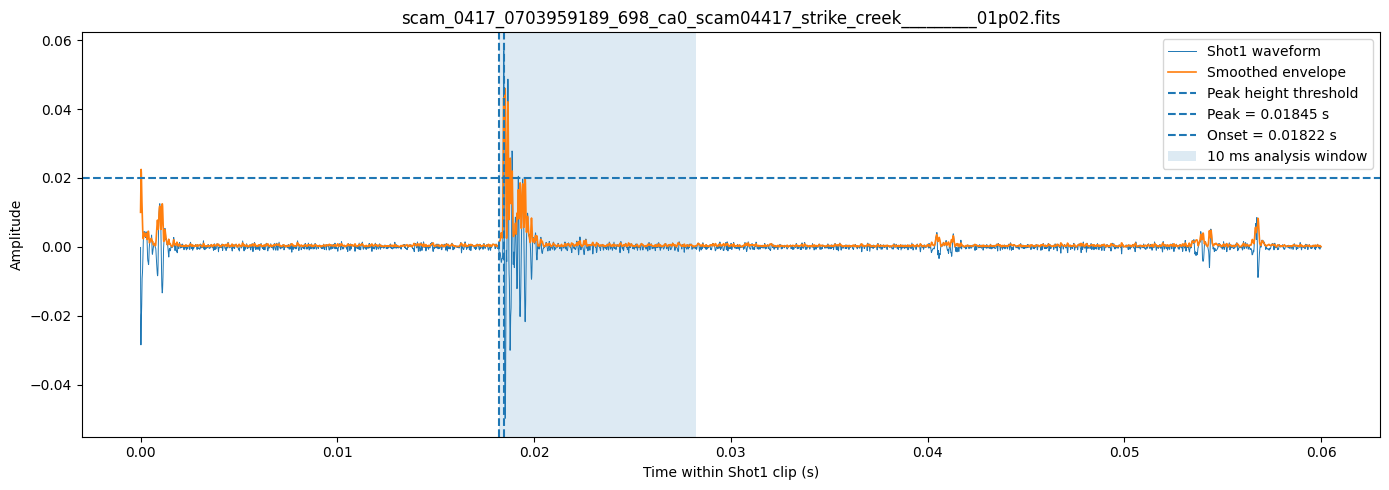

In [10]:
from pathlib import Path
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks


# ============================================================
# SETTINGS MATCHING THE CRATER-FLOOR PIPELINE
# ============================================================

FS = 100_000
SHOT_COLUMN = "Shot1"

smooth_window_s = 0.00005
height_sigma = 4
prominence_sigma = 3

backtrack_window_s = 0.003
backtrack_noise_s = 0.005
backtrack_sigma = 4
min_run_s = 0.00005

flag_lag_ms = 1.0
response_window_s = 0.010


# ============================================================
# READ SHOT1 FROM FITS
# ============================================================

with fits.open(test_fits, memmap=False) as hdul:

    sound_hdu = hdul["SOUND"]

    if SHOT_COLUMN not in sound_hdu.columns.names:
        raise KeyError(
            f"{SHOT_COLUMN} not found. "
            f"Available columns: {sound_hdu.columns.names}"
        )

    x = np.asarray(
        sound_hdu.data[SHOT_COLUMN],
        dtype=float
    ).reshape(-1)


x = x[np.isfinite(x)]
x = x - np.mean(x)

time = np.arange(len(x)) / FS


# ============================================================
# ENVELOPE
# ============================================================

abs_x = np.abs(x)

smooth_n = max(
    1,
    int(round(smooth_window_s * FS))
)

kernel = np.ones(smooth_n) / smooth_n

env = np.convolve(
    abs_x,
    kernel,
    mode="same"
)


# ============================================================
# SEARCH REGION
# ============================================================
# The FITS column is already one isolated shot.
# Avoid only the extreme edges of the clip.

search_start_s = 0.002
search_end_s = len(x) / FS - response_window_s

isearch0 = int(round(search_start_s * FS))
isearch1 = int(round(search_end_s * FS))

if isearch1 <= isearch0:
    raise ValueError("Search window is empty.")

search_env = env[isearch0:isearch1]


# ============================================================
# INITIAL NOISE ESTIMATE
# ============================================================
# Use the beginning of the isolated shot as the pre-shot noise.
# Stop before the search region begins.

noise_env = env[:isearch0]

if len(noise_env) == 0:
    raise ValueError("Noise window is empty.")

noise_mean = np.mean(noise_env)
noise_std = np.std(noise_env)

min_height = noise_mean + height_sigma * noise_std
min_prominence = prominence_sigma * noise_std


# ============================================================
# PEAK DETECTION
# ============================================================

peaks, properties = find_peaks(
    search_env,
    height=min_height,
    prominence=min_prominence
)

found_onset = len(peaks) > 0

flagged = False
lag_ms = np.nan
onset_index = None
peak_index = None


# ============================================================
# BACKTRACK FROM FIRST VALID PEAK
# ============================================================

if found_onset:

    best_peak_local = peaks[0]
    peak_index = isearch0 + best_peak_local
    peak_time = peak_index / FS

    backtrack_samples = int(
        round(backtrack_window_s * FS)
    )

    back_start = max(
        isearch0,
        peak_index - backtrack_samples
    )

    noise_back_start = max(
        0,
        back_start - int(
            round(backtrack_noise_s * FS)
        )
    )

    noise_back_end = back_start

    local_noise = env[
        noise_back_start:noise_back_end
    ]

    if len(local_noise) > 0:

        local_noise_mean = np.mean(local_noise)
        local_noise_std = np.std(local_noise)

        onset_threshold = (
            local_noise_mean
            + backtrack_sigma * local_noise_std
        )

    else:
        onset_threshold = min_height

    search_back_env = env[
        back_start:peak_index
    ]

    above = search_back_env > onset_threshold

    min_run_samples = max(
        1,
        int(round(min_run_s * FS))
    )

    for i in range(
        len(above) - min_run_samples + 1
    ):
        if np.all(
            above[i:i + min_run_samples]
        ):
            onset_index = back_start + i
            break

    if onset_index is None:
        onset_index = peak_index
        flagged = True

        print(
            "Warning: no clean onset found before peak. "
            "Using peak as onset."
        )

    onset_time = onset_index / FS

    lag_ms = (
        peak_index - onset_index
    ) / FS * 1000

    if lag_ms > flag_lag_ms:
        flagged = True

        print(
            f"Warning: peak is {lag_ms:.3f} ms "
            "after onset. Review this file."
        )

else:
    onset_time = np.nan
    peak_time = np.nan
    onset_threshold = np.nan

    print("No peak detected in the shot clip.")


# ============================================================
# EXTRACT 10 MS RESPONSE
# ============================================================

if found_onset:

    i0 = onset_index
    i1 = min(
        len(x),
        onset_index
        + int(round(response_window_s * FS))
    )

    segment = x[i0:i1]

    if len(segment) == 0:
        raise ValueError("Segment is empty.")

else:
    segment = None


# ============================================================
# OUTPUT
# ============================================================

print(f"File: {test_fits.name}")
print(f"Shot column: {SHOT_COLUMN}")
print(f"Detected peak: {peak_time:.6f} s")
print(f"Detected onset: {onset_time:.6f} s")
print(f"Peak-onset lag: {lag_ms:.3f} ms")
print(f"Flagged: {flagged}")

if segment is not None:
    print(
        f"Segment duration: "
        f"{len(segment) / FS * 1000:.3f} ms"
    )


# ============================================================
# PLOT
# ============================================================

plt.figure(figsize=(14, 5))

plt.plot(
    time,
    x,
    linewidth=0.7,
    label="Shot1 waveform"
)

plt.plot(
    time,
    env,
    linewidth=1.2,
    label="Smoothed envelope"
)

plt.axhline(
    min_height,
    linestyle="--",
    label="Peak height threshold"
)

if found_onset:

    plt.axvline(
        peak_time,
        linestyle="--",
        label=f"Peak = {peak_time:.5f} s"
    )

    plt.axvline(
        onset_time,
        linestyle="--",
        label=f"Onset = {onset_time:.5f} s"
    )

    plt.axvspan(
        onset_time,
        min(
            onset_time + response_window_s,
            len(x) / FS
        ),
        alpha=0.15,
        label="10 ms analysis window"
    )

plt.xlabel("Time within Shot1 clip (s)")
plt.ylabel("Amplitude")
plt.title(test_fits.name)

plt.legend()
plt.tight_layout()
plt.show()

Testing 10 FITS files...


,Unit,File,Onset_ms,Peak_ms,Lag_ms,Flagged,Status
0,Delta,scam_0607_0720824559_854_ca0_scam01607_gibralt...,8.77,8.96,0.19,False,OK
1,Delta,scam_0476_0709196462_557_ca0_scam01476_fourway...,9.42,9.81,0.39,False,OK
2,Delta,scam_0556_0716301226_744_ca0_scam04556_alagogs...,25.28,25.60,0.32,False,OK
3,Delta,scam_0441_0706089478_536_ca0_scam01441_little_...,14.78,15.00,0.22,False,OK
4,Delta,scam_0704_0729440506_822_ca0_scam01704_trayfoo...,NaN,NaN,NaN,True,NO PEAK
5,Upper Fan,scam_0905_0747275749_463_ca0_scam01905_radial_...,9.89,10.15,0.26,False,OK
6,Upper Fan,scam_0728_0731562419_624_ca0_scam01728_stack_r...,17.16,17.40,0.24,False,OK
7,Upper Fan,scam_0782_0736362087_277_ca0_scam01782_finch_l...,13.13,14.70,1.57,True,LONG PEAK-ONSET LAG
8,Upper Fan,scam_0873_0744435707_931_ca0_scam02873_aegis_0...,14.99,16.11,1.12,True,LONG PEAK-ONSET LAG
9,Upper Fan,scam_0870_0744168720_656_ca0_scam01870_lake_lo...,NaN,NaN,NaN,True,NO PEAK



Summary
Successful detections: 8
Flagged: 4
Mean onset: 14.178 ms
Onset standard deviation: 5.406 ms
Minimum onset: 8.770 ms
Maximum onset: 25.280 ms


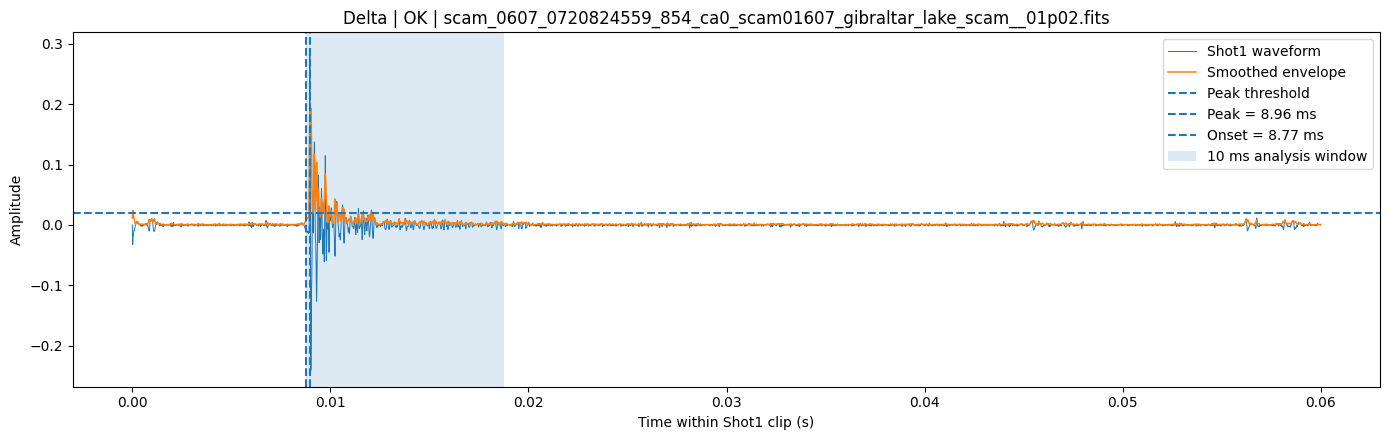

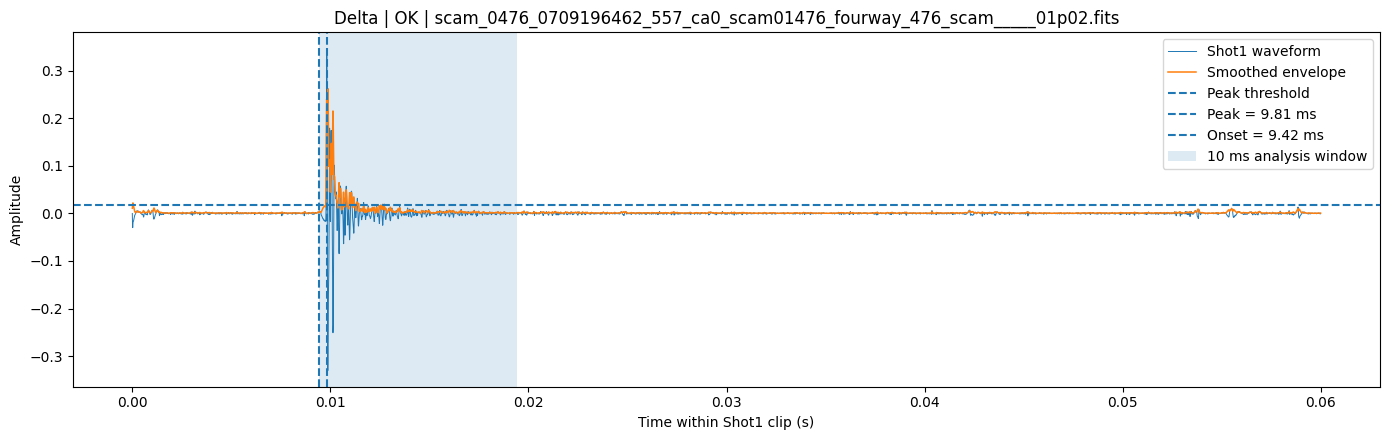

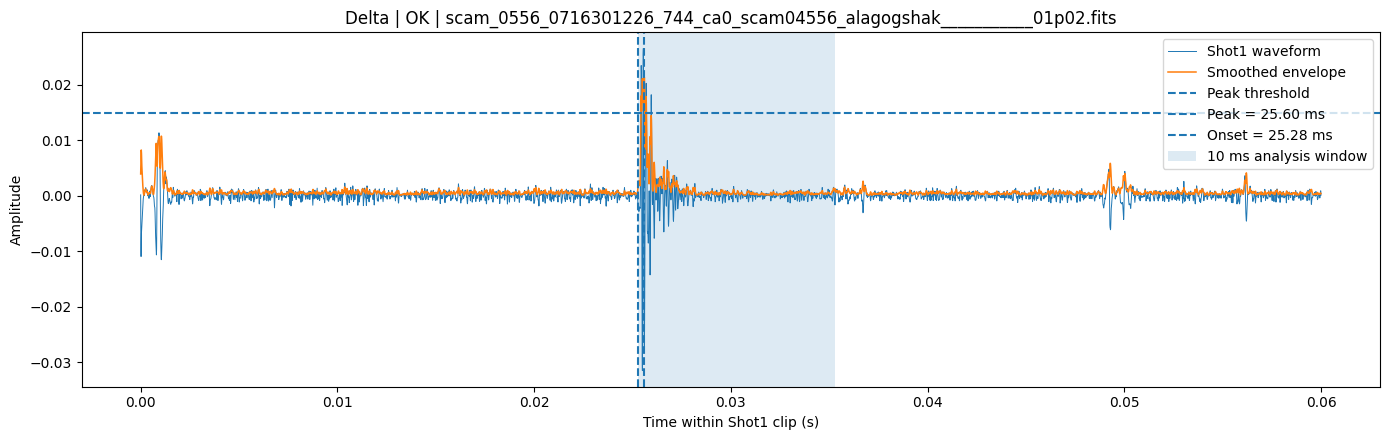

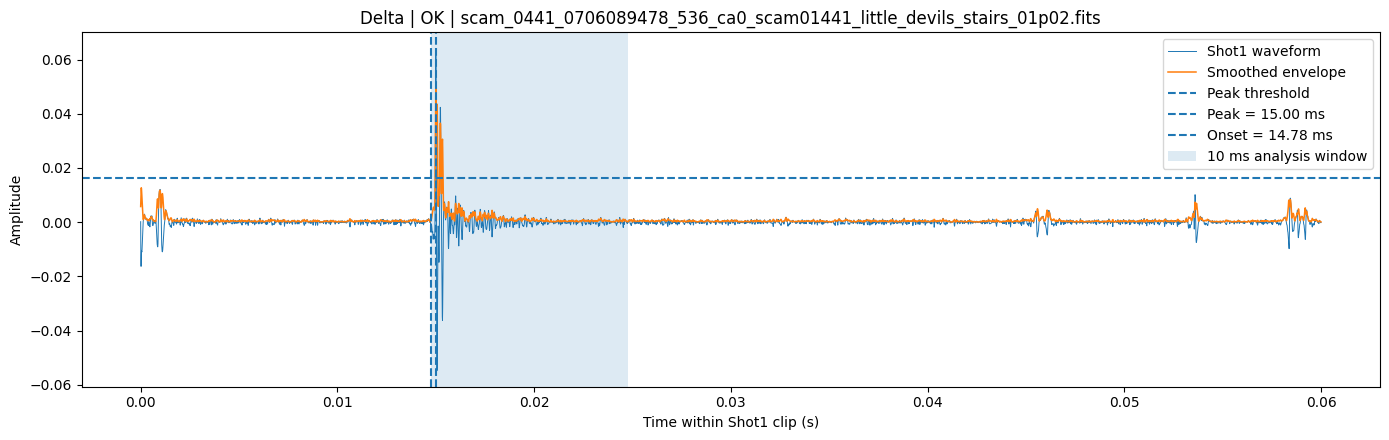

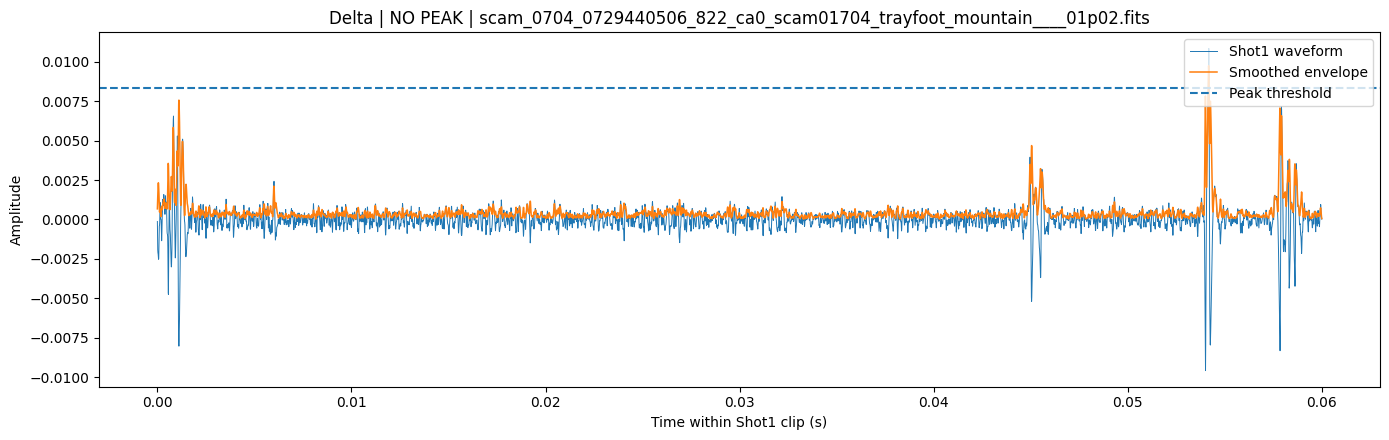

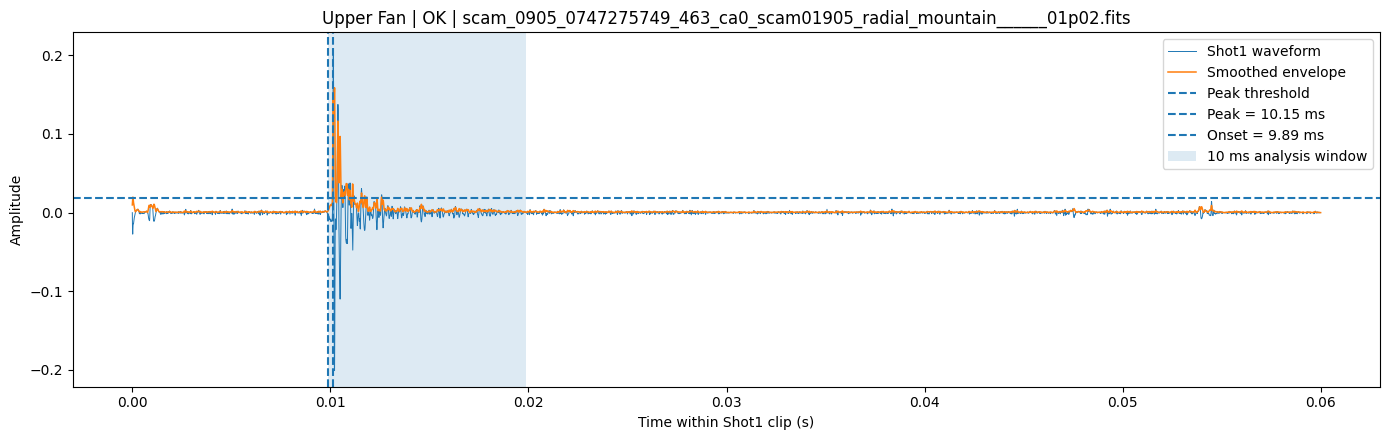

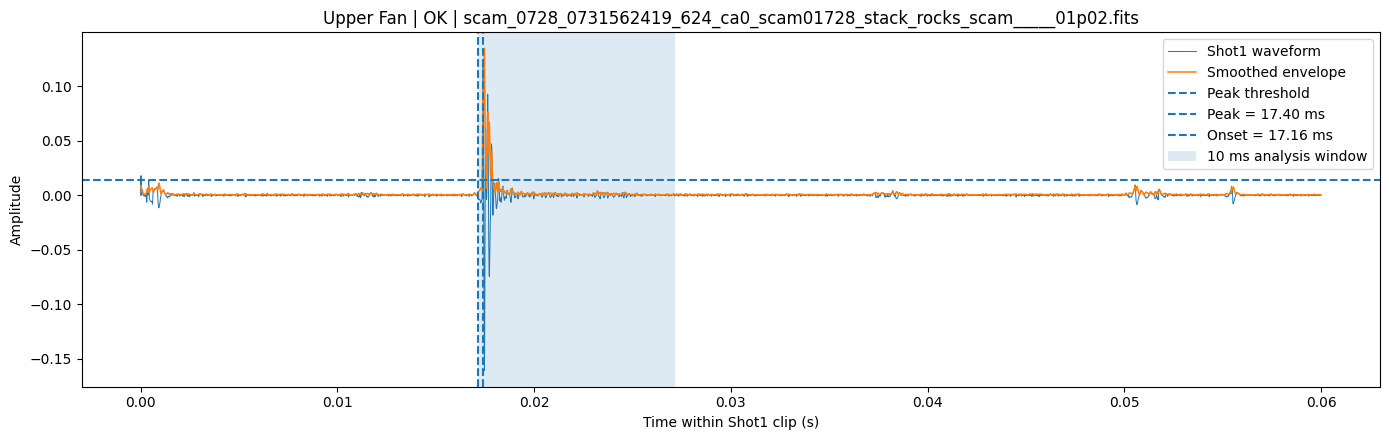

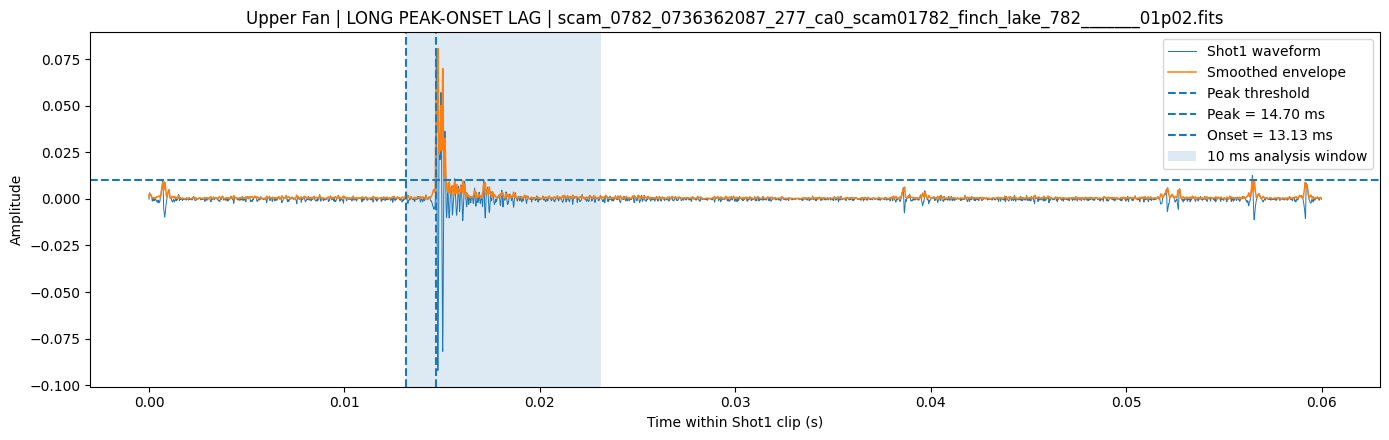

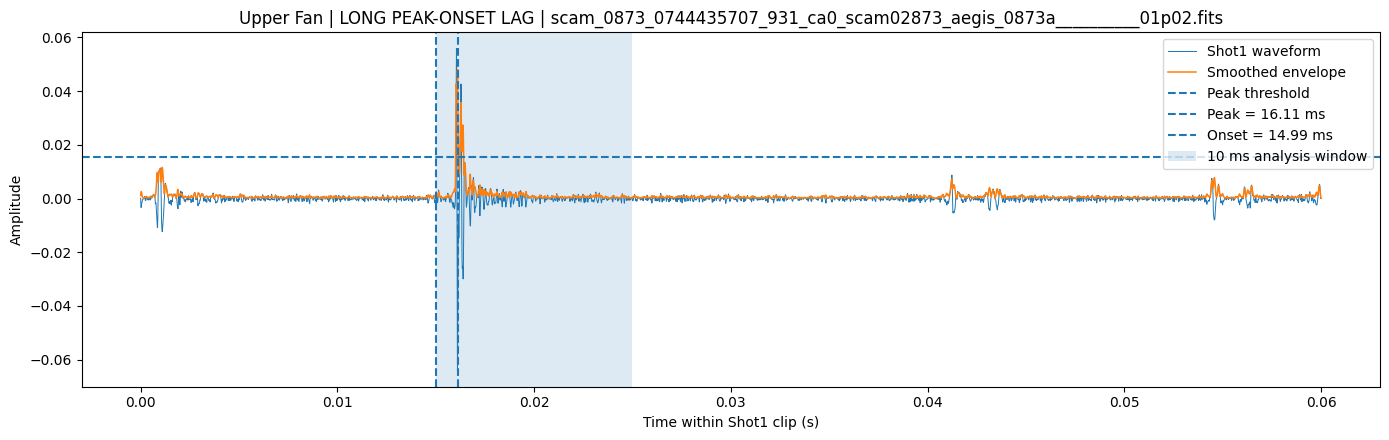

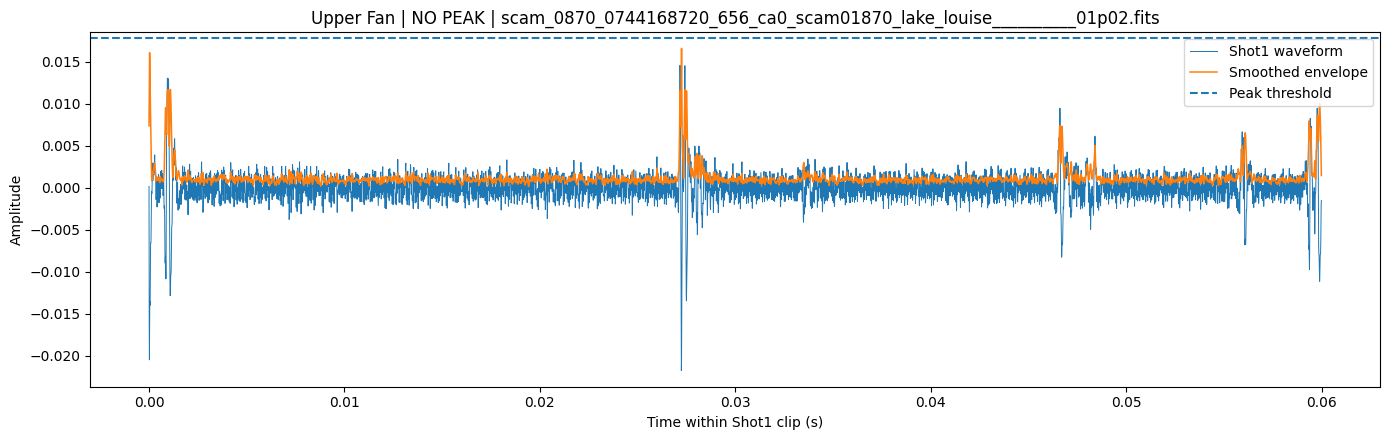

In [11]:
from pathlib import Path
from astropy.io import fits
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks


# ============================================================
# SETTINGS
# ============================================================

FS = 100_000
SHOT_COLUMN = "Shot1"

N_PER_FOLDER = 5
RANDOM_SEED = 42

smooth_window_s = 0.00005
height_sigma = 4
prominence_sigma = 3

backtrack_window_s = 0.003
backtrack_noise_s = 0.005
backtrack_sigma = 4
min_run_s = 0.00005

flag_lag_ms = 1.0
response_window_s = 0.010

DATA_FOLDERS = {
    "Delta": Path(
        r"C:\Users\cmkua\Downloads\Extracted First FITS\Delta"
    ),
    "Upper Fan": Path(
        r"C:\Users\cmkua\Downloads\Extracted First FITS\Upper Fan"
    ),
}


# ============================================================
# ONSET DETECTOR
# ============================================================

def detect_shot_onset(
    fits_path,
    shot_column="Shot1",
    fs=100_000,
):
    with fits.open(fits_path, memmap=False) as hdul:

        sound_hdu = hdul["SOUND"]

        if shot_column not in sound_hdu.columns.names:
            raise KeyError(
                f"{shot_column} not found in {fits_path.name}"
            )

        x = np.asarray(
            sound_hdu.data[shot_column],
            dtype=float
        ).reshape(-1)

    finite_mask = np.isfinite(x)

    if not np.all(finite_mask):
        x = x[finite_mask]

    x = x - np.mean(x)

    time = np.arange(len(x)) / fs

    # --------------------------------------------------------
    # Smoothed absolute-amplitude envelope
    # --------------------------------------------------------

    smooth_n = max(
        1,
        int(round(smooth_window_s * fs))
    )

    env = np.convolve(
        np.abs(x),
        np.ones(smooth_n) / smooth_n,
        mode="same"
    )

    # --------------------------------------------------------
    # Search region
    # --------------------------------------------------------

    search_start_s = 0.002
    search_end_s = len(x) / fs - response_window_s

    isearch0 = int(round(search_start_s * fs))
    isearch1 = int(round(search_end_s * fs))

    if isearch1 <= isearch0:
        raise ValueError(
            f"Invalid search region in {fits_path.name}"
        )

    search_env = env[isearch0:isearch1]

    # --------------------------------------------------------
    # Initial noise threshold
    # --------------------------------------------------------

    noise_env = env[:isearch0]

    if len(noise_env) == 0:
        raise ValueError(
            f"Empty noise region in {fits_path.name}"
        )

    noise_mean = np.mean(noise_env)
    noise_std = np.std(noise_env)

    min_height = (
        noise_mean
        + height_sigma * noise_std
    )

    min_prominence = (
        prominence_sigma * noise_std
    )

    # --------------------------------------------------------
    # Peak detection
    # --------------------------------------------------------

    peaks, properties = find_peaks(
        search_env,
        height=min_height,
        prominence=min_prominence
    )

    if len(peaks) == 0:
        return {
            "file": fits_path.name,
            "status": "NO PEAK",
            "onset_s": np.nan,
            "peak_s": np.nan,
            "lag_ms": np.nan,
            "flagged": True,
            "signal": x,
            "envelope": env,
            "time": time,
            "threshold": min_height,
            "onset_threshold": np.nan,
            "onset_index": None,
            "peak_index": None,
        }

    # Use first valid peak, matching crater-floor logic
    peak_index = isearch0 + int(peaks[0])

    # --------------------------------------------------------
    # Backtrack from detected peak
    # --------------------------------------------------------

    backtrack_samples = int(
        round(backtrack_window_s * fs)
    )

    second_shot_start_index = int(round(second_shot_start * fs))

    back_start = max(
        second_shot_start_index,
        peak_index - backtrack_samples,
    )

    noise_back_start = max(
        0,
        back_start
        - int(round(backtrack_noise_s * fs))
    )

    local_noise = env[
        noise_back_start:back_start
    ]

    if len(local_noise) > 0:

        local_noise_mean = np.mean(local_noise)
        local_noise_std = np.std(local_noise)

        onset_threshold = (
            local_noise_mean
            + backtrack_sigma * local_noise_std
        )

    else:
        onset_threshold = min_height

    search_back_env = env[
        back_start:peak_index
    ]

    above = (
        search_back_env
        > onset_threshold
    )

    min_run_samples = max(
        1,
        int(round(min_run_s * fs))
    )

    onset_index = None

    for i in range(
        len(above) - min_run_samples + 1
    ):
        if np.all(
            above[i:i + min_run_samples]
        ):
            onset_index = back_start + i
            break

    flagged = False
    status = "OK"

    if onset_index is None:
        onset_index = peak_index
        flagged = True
        status = "PEAK USED AS ONSET"

    onset_s = onset_index / fs
    peak_s = peak_index / fs

    lag_ms = (
        peak_index - onset_index
    ) / fs * 1000

    if lag_ms > flag_lag_ms:
        flagged = True
        status = "LONG PEAK-ONSET LAG"

    # Check whether full 10 ms window fits
    segment_end = (
        onset_index
        + int(round(response_window_s * fs))
    )

    if segment_end > len(x):
        flagged = True
        status = "SHORT ANALYSIS WINDOW"

    return {
        "file": fits_path.name,
        "status": status,
        "onset_s": onset_s,
        "peak_s": peak_s,
        "lag_ms": lag_ms,
        "flagged": flagged,
        "signal": x,
        "envelope": env,
        "time": time,
        "threshold": min_height,
        "onset_threshold": onset_threshold,
        "onset_index": onset_index,
        "peak_index": peak_index,
    }


# ============================================================
# RANDOMLY SELECT TEST FILES
# ============================================================

rng = np.random.default_rng(RANDOM_SEED)

selected_files = []

for unit, folder in DATA_FOLDERS.items():

    files = sorted(folder.glob("*.fits"))

    if len(files) == 0:
        print(f"No FITS files found in {folder}")
        continue

    n_select = min(
        N_PER_FOLDER,
        len(files)
    )

    chosen_indices = rng.choice(
        len(files),
        size=n_select,
        replace=False
    )

    for index in chosen_indices:
        selected_files.append(
            (unit, files[index])
        )

print(
    f"Testing {len(selected_files)} FITS files..."
)


# ============================================================
# RUN DETECTOR
# ============================================================

results = []

for unit, fits_path in selected_files:

    try:
        result = detect_shot_onset(
            fits_path,
            shot_column=SHOT_COLUMN,
            fs=FS
        )

        result["unit"] = unit
        results.append(result)

    except Exception as exc:

        results.append({
            "unit": unit,
            "file": fits_path.name,
            "status": f"ERROR: {exc}",
            "onset_s": np.nan,
            "peak_s": np.nan,
            "lag_ms": np.nan,
            "flagged": True,
            "signal": None,
            "envelope": None,
            "time": None,
            "threshold": np.nan,
            "onset_threshold": np.nan,
            "onset_index": None,
            "peak_index": None,
        })


# ============================================================
# SUMMARY TABLE
# ============================================================

summary_df = pd.DataFrame([
    {
        "Unit": result["unit"],
        "File": result["file"],
        "Onset_ms": (
            result["onset_s"] * 1000
            if np.isfinite(result["onset_s"])
            else np.nan
        ),
        "Peak_ms": (
            result["peak_s"] * 1000
            if np.isfinite(result["peak_s"])
            else np.nan
        ),
        "Lag_ms": result["lag_ms"],
        "Flagged": result["flagged"],
        "Status": result["status"],
    }
    for result in results
])

display(summary_df)

print("\nSummary")
print("=" * 50)
print(
    f"Successful detections: "
    f"{summary_df['Onset_ms'].notna().sum()}"
)
print(
    f"Flagged: "
    f"{summary_df['Flagged'].sum()}"
)

if summary_df["Onset_ms"].notna().any():

    print(
        f"Mean onset: "
        f"{summary_df['Onset_ms'].mean():.3f} ms"
    )

    print(
        f"Onset standard deviation: "
        f"{summary_df['Onset_ms'].std():.3f} ms"
    )

    print(
        f"Minimum onset: "
        f"{summary_df['Onset_ms'].min():.3f} ms"
    )

    print(
        f"Maximum onset: "
        f"{summary_df['Onset_ms'].max():.3f} ms"
    )


# ============================================================
# PLOT EACH TEST FILE
# ============================================================

for result in results:

    if result["signal"] is None:
        print(
            f"Skipping plot for {result['file']}: "
            f"{result['status']}"
        )
        continue

    time = result["time"]
    x = result["signal"]
    env = result["envelope"]

    plt.figure(figsize=(14, 4.5))

    plt.plot(
        time,
        x,
        linewidth=0.7,
        label="Shot1 waveform"
    )

    plt.plot(
        time,
        env,
        linewidth=1.1,
        label="Smoothed envelope"
    )

    plt.axhline(
        result["threshold"],
        linestyle="--",
        label="Peak threshold"
    )

    if result["peak_index"] is not None:

        peak_s = (
            result["peak_index"] / FS
        )

        plt.axvline(
            peak_s,
            linestyle="--",
            label=f"Peak = {peak_s * 1000:.2f} ms"
        )

    if result["onset_index"] is not None:

        onset_s = (
            result["onset_index"] / FS
        )

        plt.axvline(
            onset_s,
            linestyle="--",
            label=f"Onset = {onset_s * 1000:.2f} ms"
        )

        plt.axvspan(
            onset_s,
            min(
                onset_s + response_window_s,
                len(x) / FS
            ),
            alpha=0.15,
            label="10 ms analysis window"
        )

    plt.xlabel("Time within Shot1 clip (s)")
    plt.ylabel("Amplitude")

    plt.title(
        f"{result['unit']} | "
        f"{result['status']} | "
        f"{result['file']}"
    )

    plt.legend(loc="upper right")
    plt.tight_layout()
    plt.show()

In [12]:
from pathlib import Path
from astropy.io import fits
import numpy as np
import pandas as pd
from scipy.signal import find_peaks


# ============================================================
# PATHS
# ============================================================

DATA_FOLDERS = {
    "Delta": Path(
        r"C:\Users\cmkua\Downloads\Extracted First FITS\Delta"
    ),
    "Upper Fan": Path(
        r"C:\Users\cmkua\Downloads\Extracted First FITS\Upper Fan"
    ),
}

OUTPUT_FOLDER = Path(
    r"C:\Users\cmkua\Downloads\Extracted First FITS"
)

OUTPUT_FOLDER.mkdir(parents=True, exist_ok=True)

ALL_RESULTS_CSV = OUTPUT_FOLDER / "all_fits_onset_results.csv"
FLAGGED_RESULTS_CSV = OUTPUT_FOLDER / "flagged_fits_onsets.csv"


# ============================================================
# DETECTOR SETTINGS
# ============================================================

FS = 100_000
SHOT_COLUMN = "Shot1"

SMOOTH_WINDOW_S = 0.00005
HEIGHT_SIGMA = 4.0
PROMINENCE_SIGMA = 3.0

SEARCH_START_S = 0.002
RESPONSE_WINDOW_S = 0.010

BACKTRACK_WINDOW_S = 0.003
BACKTRACK_NOISE_S = 0.005
BACKTRACK_SIGMA = 4.0
MIN_RUN_S = 0.00005

FLAG_LAG_MS = 1.0


# ============================================================
# DETECT ONSET IN ONE FITS
# ============================================================

def detect_fits_onset(fits_path, unit):
    result = {
        "Unit": unit,
        "File": fits_path.name,
        "Full_Path": str(fits_path),
        "Shot_Column": SHOT_COLUMN,
        "Num_Sound_Shots": np.nan,
        "Num_Samples": np.nan,
        "Duration_ms": np.nan,
        "Onset_Sample": np.nan,
        "Onset_ms": np.nan,
        "Peak_Sample": np.nan,
        "Peak_ms": np.nan,
        "Lag_ms": np.nan,
        "Peak_Amplitude": np.nan,
        "Signal_RMS": np.nan,
        "Threshold": np.nan,
        "Flagged": True,
        "Status": "UNPROCESSED",
    }

    try:
        # ----------------------------------------------------
        # Read Shot1
        # ----------------------------------------------------

        with fits.open(fits_path, memmap=False) as hdul:
            sound_hdu = hdul["SOUND"]
            shot_names = list(sound_hdu.columns.names)

            result["Num_Sound_Shots"] = len(shot_names)

            if SHOT_COLUMN not in shot_names:
                result["Status"] = "SHOT1 MISSING"
                return result

            x = np.asarray(
                sound_hdu.data[SHOT_COLUMN],
                dtype=float
            ).reshape(-1)

        if len(x) == 0:
            result["Status"] = "EMPTY SHOT"
            return result

        if not np.all(np.isfinite(x)):
            result["Status"] = "NONFINITE VALUES"
            return result

        result["Num_Samples"] = len(x)
        result["Duration_ms"] = len(x) / FS * 1000

        # Remove DC offset
        x = x - np.mean(x)

        result["Signal_RMS"] = np.sqrt(np.mean(x**2))

        # ----------------------------------------------------
        # Smoothed absolute-amplitude envelope
        # ----------------------------------------------------

        smooth_n = max(
            1,
            int(round(SMOOTH_WINDOW_S * FS))
        )

        env = np.convolve(
            np.abs(x),
            np.ones(smooth_n) / smooth_n,
            mode="same"
        )

        # ----------------------------------------------------
        # Search region
        # ----------------------------------------------------

        search_start = int(round(SEARCH_START_S * FS))

        search_end = (
            len(x)
            - int(round(RESPONSE_WINDOW_S * FS))
        )

        if search_end <= search_start:
            result["Status"] = "INVALID SEARCH WINDOW"
            return result

        search_env = env[search_start:search_end]

        # ----------------------------------------------------
        # Initial noise estimate
        # ----------------------------------------------------

        noise_env = env[:search_start]

        if len(noise_env) == 0:
            result["Status"] = "EMPTY NOISE WINDOW"
            return result

        noise_mean = np.mean(noise_env)
        noise_std = np.std(noise_env)

        peak_threshold = (
            noise_mean
            + HEIGHT_SIGMA * noise_std
        )

        prominence_threshold = (
            PROMINENCE_SIGMA * noise_std
        )

        result["Threshold"] = peak_threshold

        # ----------------------------------------------------
        # Find candidate peaks
        # ----------------------------------------------------

        peaks, properties = find_peaks(
            search_env,
            height=peak_threshold,
            prominence=prominence_threshold
        )

        if len(peaks) == 0:
            result["Status"] = "NO PEAK"
            return result

        # Match previous crater-floor logic:
        # use the first valid peak.
        peak_index = search_start + int(peaks[0])

        result["Peak_Sample"] = peak_index
        result["Peak_ms"] = peak_index / FS * 1000
        result["Peak_Amplitude"] = x[peak_index]

        # ----------------------------------------------------
        # Backtrack to onset
        # ----------------------------------------------------

        backtrack_samples = int(
            round(BACKTRACK_WINDOW_S * FS)
        )

        back_start = max(
            search_start,
            peak_index - backtrack_samples
        )

        back_noise_start = max(
            0,
            back_start
            - int(round(BACKTRACK_NOISE_S * FS))
        )

        local_noise = env[
            back_noise_start:back_start
        ]

        if len(local_noise) > 0:
            onset_threshold = (
                np.mean(local_noise)
                + BACKTRACK_SIGMA
                * np.std(local_noise)
            )
        else:
            onset_threshold = peak_threshold

        back_env = env[
            back_start:peak_index
        ]

        above = back_env > onset_threshold

        min_run_samples = max(
            1,
            int(round(MIN_RUN_S * FS))
        )

        onset_index = None

        for i in range(
            len(above) - min_run_samples + 1
        ):
            if np.all(
                above[i:i + min_run_samples]
            ):
                onset_index = back_start + i
                break

        if onset_index is None:
            onset_index = peak_index
            status = "PEAK USED AS ONSET"
            flagged = True

        else:
            lag_ms = (
                peak_index - onset_index
            ) / FS * 1000

            if lag_ms > FLAG_LAG_MS:
                status = "LONG PEAK-ONSET LAG"
                flagged = True
            else:
                status = "OK"
                flagged = False

        # ----------------------------------------------------
        # Check that full 10 ms segment exists
        # ----------------------------------------------------

        segment_end = (
            onset_index
            + int(round(RESPONSE_WINDOW_S * FS))
        )

        if segment_end > len(x):
            status = "SHORT ANALYSIS WINDOW"
            flagged = True

        result["Onset_Sample"] = onset_index
        result["Onset_ms"] = onset_index / FS * 1000
        result["Lag_ms"] = (
            peak_index - onset_index
        ) / FS * 1000
        result["Flagged"] = flagged
        result["Status"] = status

        return result

    except Exception as exc:
        result["Status"] = f"ERROR: {exc}"
        result["Flagged"] = True
        return result


# ============================================================
# COLLECT ALL FITS FILES
# ============================================================

all_files = []

for unit, folder in DATA_FOLDERS.items():
    files = sorted(folder.glob("*.fits"))

    print(f"{unit}: {len(files)} FITS files")

    for fits_path in files:
        all_files.append((unit, fits_path))

print(f"\nTotal FITS files: {len(all_files)}")


# ============================================================
# RUN ALL FILES
# ============================================================

results = []

for number, (unit, fits_path) in enumerate(
    all_files,
    start=1
):
    result = detect_fits_onset(
        fits_path=fits_path,
        unit=unit
    )

    results.append(result)

    print(
        f"[{number:03d}/{len(all_files):03d}] "
        f"{unit:<10} "
        f"{fits_path.name[:45]:<45} "
        f"{result['Status']}"
    )


# ============================================================
# CREATE DATAFRAMES
# ============================================================

onset_df = pd.DataFrame(results)

flagged_df = onset_df[
    onset_df["Flagged"] == True
].copy()

clean_df = onset_df[
    onset_df["Flagged"] == False
].copy()


# ============================================================
# SAVE RESULTS
# ============================================================

onset_df.to_csv(
    ALL_RESULTS_CSV,
    index=False
)

flagged_df.to_csv(
    FLAGGED_RESULTS_CSV,
    index=False
)


# ============================================================
# SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("ONSET DETECTION SUMMARY")
print("=" * 70)

print(f"Total files: {len(onset_df)}")
print(f"Clean detections: {len(clean_df)}")
print(f"Flagged files: {len(flagged_df)}")

print("\nStatus counts:")
print(onset_df["Status"].value_counts(dropna=False))

print("\nResults by unit:")
print(
    onset_df.groupby(
        ["Unit", "Status"]
    ).size()
)

if len(clean_df) > 0:
    print("\nClean onset statistics:")

    print(
        f"Mean onset: "
        f"{clean_df['Onset_ms'].mean():.3f} ms"
    )

    print(
        f"Median onset: "
        f"{clean_df['Onset_ms'].median():.3f} ms"
    )

    print(
        f"Minimum onset: "
        f"{clean_df['Onset_ms'].min():.3f} ms"
    )

    print(
        f"Maximum onset: "
        f"{clean_df['Onset_ms'].max():.3f} ms"
    )

    print(
        f"Mean peak-onset lag: "
        f"{clean_df['Lag_ms'].mean():.3f} ms"
    )

print("\nSaved:")
print(ALL_RESULTS_CSV)
print(FLAGGED_RESULTS_CSV)


# Show flagged files
display(
    flagged_df[
        [
            "Unit",
            "File",
            "Onset_ms",
            "Peak_ms",
            "Lag_ms",
            "Status",
        ]
    ]
)

Delta: 125 FITS files
Upper Fan: 100 FITS files

Total FITS files: 225
[001/225] Delta      scam_0417_0703959189_698_ca0_scam04417_strike OK
[002/225] Delta      scam_0418_0704038328_265_ca0_scam02418_little OK
[003/225] Delta      scam_0420_0704221258_808_ca0_scam01420_broken OK
[004/225] Delta      scam_0421_0704313596_618_ca0_scam05421_king_s OK
[005/225] Delta      scam_0422_0704402454_571_ca0_scam04422_kaguya NO PEAK
[006/225] Delta      scam_0424_0704579883_996_ca0_scam06424_cape_g OK
[007/225] Delta      scam_0424_0704582132_115_ca0_scam07424_hook_g OK
[008/225] Delta      scam_0425_0704655931_247_ca0_scam01425_angle_ OK
[009/225] Delta      scam_0425_0704668824_603_ca0_scam04425_lake_c OK
[010/225] Delta      scam_0425_0704671054_732_ca0_scam05425_sukoi_ NO PEAK
[011/225] Delta      scam_0441_0706089478_536_ca0_scam01441_little OK
[012/225] Delta      scam_0441_0706090425_650_ca0_scam02441_bald_f OK
[013/225] Delta      scam_0442_0706165848_775_ca0_scam15012_aegis_ OK
[014/225]

,Unit,File,Onset_ms,Peak_ms,Lag_ms,Status
4,Delta,scam_0422_0704402454_571_ca0_scam04422_kaguyak...,NaN,NaN,NaN,NO PEAK
9,Delta,scam_0425_0704671054_732_ca0_scam05425_sukoi_b...,NaN,NaN,NaN,NO PEAK
21,Delta,scam_0451_0706979740_413_ca0_scam02451_marys_r...,10.07,12.65,2.58,LONG PEAK-ONSET LAG
45,Delta,scam_0465_0708221048_464_ca0_scam01465_calvary...,NaN,NaN,NaN,NO PEAK
56,Delta,scam_0482_0709729164_771_ca0_scam01482_goat_ho...,NaN,NaN,NaN,NO PEAK
74,Delta,scam_0533_0714247728_852_ca0_scam01533_corbin_...,16.35,18.27,1.92,LONG PEAK-ONSET LAG
79,Delta,scam_0554_0716124210_576_ca0_scam02554_barrier...,18.38,20.65,2.27,LONG PEAK-ONSET LAG
85,Delta,scam_0563_0716919971_591_ca0_scam01563_swiksha...,10.28,13.09,2.81,LONG PEAK-ONSET LAG
86,Delta,scam_0565_0717087207_245_ca0_scam01565_raspber...,10.94,13.05,2.11,LONG PEAK-ONSET LAG
99,Delta,scam_0613_0721361671_354_ci__scam03613_gorge_c...,NaN,NaN,NaN,"ERROR: ""Extension 'SOUND' not found."""


In [3]:
from pathlib import Path
from zipfile import ZipFile
from io import BytesIO
import csv

import numpy as np
from astropy.io import fits
from scipy.io import wavfile


# ============================================================
# PATHS
# ============================================================

# Change these only if your folder names differ
ROOT = Path(r"C:\Users\cmkua\Downloads")

ZIP_FOLDERS = {
    "Delta": ROOT / "Delta",
    "Upper Fan": ROOT / "Upper Fan",
}

OUTPUT_ROOT = ROOT / "Concatenated Multishot WAVs"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

FS = 100_000


# ============================================================
# HELPERS
# ============================================================

def shot_number(column_name):
    """Return the integer in Shot0, Shot1, etc."""
    return int(column_name.lower().replace("shot", ""))


def find_desired_fits(zip_file):
    """
    Find FITS products ending in 01p02.fits inside one ZIP.

    Returns every match because some AEGIS ZIPs may contain
    multiple desired FITS files.
    """
    names = [
        name for name in zip_file.namelist()
        if name.lower().endswith("01p02.fits")
    ]

    return sorted(names)


def read_concatenated_sound(zip_file, fits_name):
    """
    Read SOUND/Shot0...ShotN from a FITS inside an open ZIP
    and concatenate the raw shot arrays in numerical order.
    """

    fits_bytes = zip_file.read(fits_name)

    with fits.open(BytesIO(fits_bytes), memmap=False) as hdul:

        if "SOUND" not in hdul:
            raise KeyError("SOUND extension not found")

        sound = hdul["SOUND"].data

        if sound is None:
            raise ValueError("SOUND extension contains no data")

        column_names = list(sound.columns.names)

        shot_columns = [
            name for name in column_names
            if name.lower().startswith("shot")
            and name[4:].isdigit()
        ]

        if not shot_columns:
            raise ValueError("No Shot columns found in SOUND")

        shot_columns.sort(key=shot_number)

        shots = []

        for column in shot_columns:
            shot = np.asarray(sound[column], dtype=np.float32).reshape(-1)

            if not np.all(np.isfinite(shot)):
                raise ValueError(f"{column} contains NaN or infinite values")

            shots.append(shot)

        waveform = np.concatenate(shots)

    return waveform, shot_columns


def make_output_name(fits_name):
    """
    Convert the FITS product name to a WAV filename while
    preserving its original identifying information.
    """
    return Path(fits_name).name[:-5] + ".wav"


# ============================================================
# PROCESS ALL ZIP FILES
# ============================================================

log_rows = []

for unit, zip_folder in ZIP_FOLDERS.items():

    output_folder = OUTPUT_ROOT / unit
    output_folder.mkdir(parents=True, exist_ok=True)

    zip_paths = sorted(zip_folder.glob("*.zip"))

    print("\n" + "=" * 80)
    print(f"{unit}: {len(zip_paths)} ZIP files")
    print("=" * 80)

    for zip_path in zip_paths:

        try:
            with ZipFile(zip_path, "r") as zf:

                fits_names = find_desired_fits(zf)

                if not fits_names:
                    raise FileNotFoundError(
                        "No file ending in 01p02.fits found"
                    )

                for fits_name in fits_names:

                    try:
                        waveform, shot_columns = read_concatenated_sound(
                            zf,
                            fits_name
                        )

                        output_name = make_output_name(fits_name)
                        output_path = output_folder / output_name

                        # Preserve the FITS floating-point waveform.
                        # scipy writes this as a 32-bit float WAV.
                        wavfile.write(
                            output_path,
                            FS,
                            waveform.astype(np.float32)
                        )

                        duration = len(waveform) / FS

                        print(
                            f"OK | {zip_path.name} | "
                            f"{Path(fits_name).name} | "
                            f"{len(shot_columns)} shots | "
                            f"{len(waveform)} samples | "
                            f"{duration:.3f} s"
                        )

                        log_rows.append({
                            "Unit": unit,
                            "ZIP": zip_path.name,
                            "FITS": Path(fits_name).name,
                            "WAV": output_name,
                            "Status": "OK",
                            "Number of shots": len(shot_columns),
                            "Samples per shot": (
                                len(waveform) // len(shot_columns)
                            ),
                            "Total samples": len(waveform),
                            "Duration (s)": duration,
                            "Error": "",
                        })

                    except Exception as exc:
                        print(
                            f"ERROR | {zip_path.name} | "
                            f"{Path(fits_name).name} | {exc}"
                        )

                        log_rows.append({
                            "Unit": unit,
                            "ZIP": zip_path.name,
                            "FITS": Path(fits_name).name,
                            "WAV": "",
                            "Status": "ERROR",
                            "Number of shots": "",
                            "Samples per shot": "",
                            "Total samples": "",
                            "Duration (s)": "",
                            "Error": str(exc),
                        })

        except Exception as exc:
            print(f"ZIP ERROR | {zip_path.name} | {exc}")

            log_rows.append({
                "Unit": unit,
                "ZIP": zip_path.name,
                "FITS": "",
                "WAV": "",
                "Status": "ZIP ERROR",
                "Number of shots": "",
                "Samples per shot": "",
                "Total samples": "",
                "Duration (s)": "",
                "Error": str(exc),
            })


# ============================================================
# SAVE LOG
# ============================================================

log_path = OUTPUT_ROOT / "concatenation_log.csv"

fieldnames = [
    "Unit",
    "ZIP",
    "FITS",
    "WAV",
    "Status",
    "Number of shots",
    "Samples per shot",
    "Total samples",
    "Duration (s)",
    "Error",
]

with open(log_path, "w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(log_rows)


# ============================================================
# SUMMARY
# ============================================================

ok_count = sum(row["Status"] == "OK" for row in log_rows)
error_count = len(log_rows) - ok_count

print("\n" + "=" * 80)
print("FINISHED")
print("=" * 80)
print(f"WAVs created: {ok_count}")
print(f"Errors:       {error_count}")
print(f"Output:       {OUTPUT_ROOT}")
print(f"Log:          {log_path}")


Delta: 116 ZIP files
OK | urn_nasa_pds_mars2020_supercam_data_calibrated_audio_scam_0417_0703959189_698_ca0_scam04417_strike_creek_________01p__2.0.zip | scam_0417_0703959189_698_ca0_scam04417_strike_creek_________01p02.fits | 29 shots | 174000 samples | 1.740 s
OK | urn_nasa_pds_mars2020_supercam_data_calibrated_audio_scam_0418_0704038328_265_ca0_scam02418_little_beach_________01p__2.0.zip | scam_0418_0704038328_265_ca0_scam02418_little_beach_________01p02.fits | 29 shots | 174000 samples | 1.740 s
OK | urn_nasa_pds_mars2020_supercam_data_calibrated_audio_scam_0420_0704221258_808_ca0_scam01420_broken_mountain______01p__2.0.zip | scam_0420_0704221258_808_ca0_scam01420_broken_mountain______01p02.fits | 29 shots | 174000 samples | 1.740 s
OK | urn_nasa_pds_mars2020_supercam_data_calibrated_audio_scam_0421_0704313596_618_ca0_scam05421_king_salmon__________01p__2.0.zip | scam_0421_0704313596_618_ca0_scam05421_king_salmon__________01p02.fits | 29 shots | 174000 samples | 1.740 s
OK | urn_n

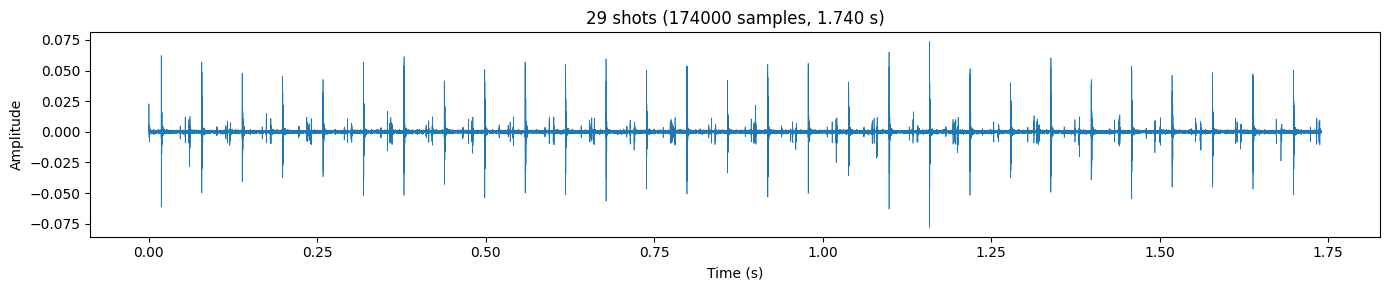

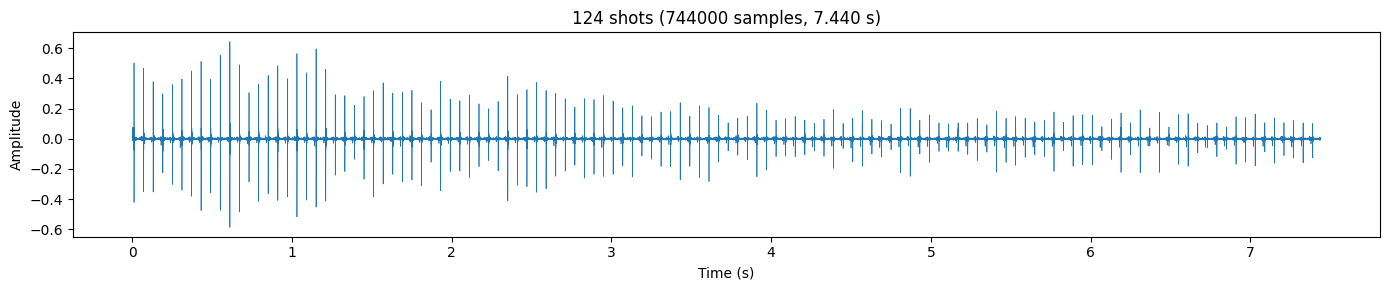

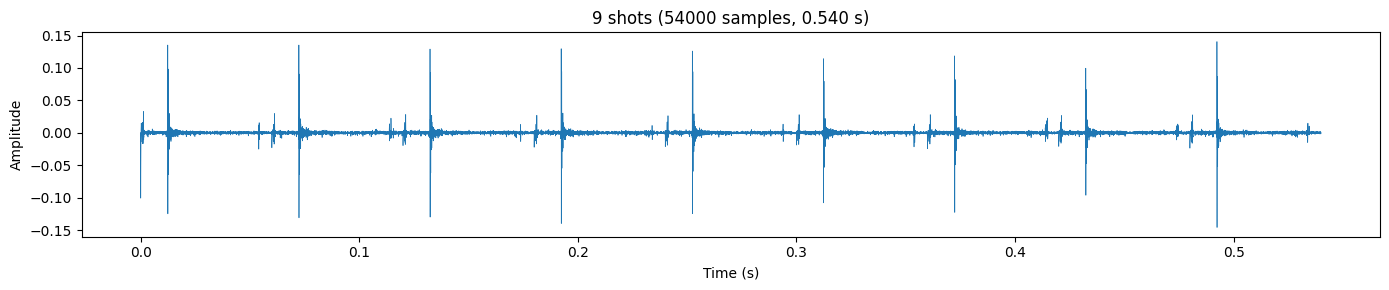

In [4]:
from scipy.io import wavfile
import matplotlib.pyplot as plt
from pathlib import Path

# Folder where the concatenated WAVs were written
wav_dir = Path(r"C:\Users\cmkua\Downloads\Concatenated Multishot WAVs\Delta")

examples = {
    "29 shots":  "scam_0417_0703959189_698_ca0_scam04417_strike_creek_________01p02.wav",
    "124 shots": "scam_0471_0708740988_825_ca0_scam01471_pinefield_gap________01p02.wav",
    "9 shots":   "scam_0454_0707256160_466_ca0_scam07454_dakavak______________01p02.wav",
}

for title, filename in examples.items():

    fs, audio = wavfile.read(wav_dir / filename)

    t = range(len(audio))

    plt.figure(figsize=(14,3))
    plt.plot([x/fs for x in t], audio, lw=0.5)
    plt.title(f"{title} ({len(audio)} samples, {len(audio)/fs:.3f} s)")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.tight_layout()
    plt.show()

Selected 5 standard 29-shot files.


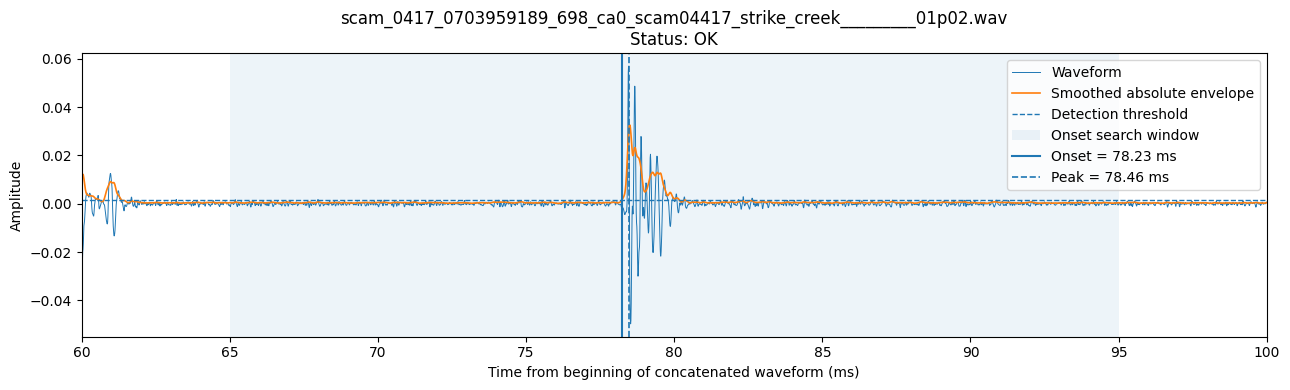

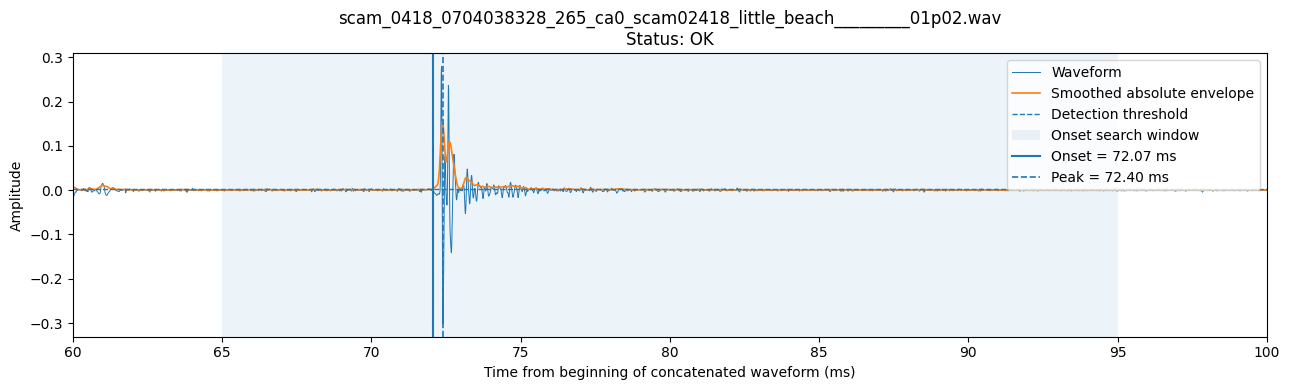

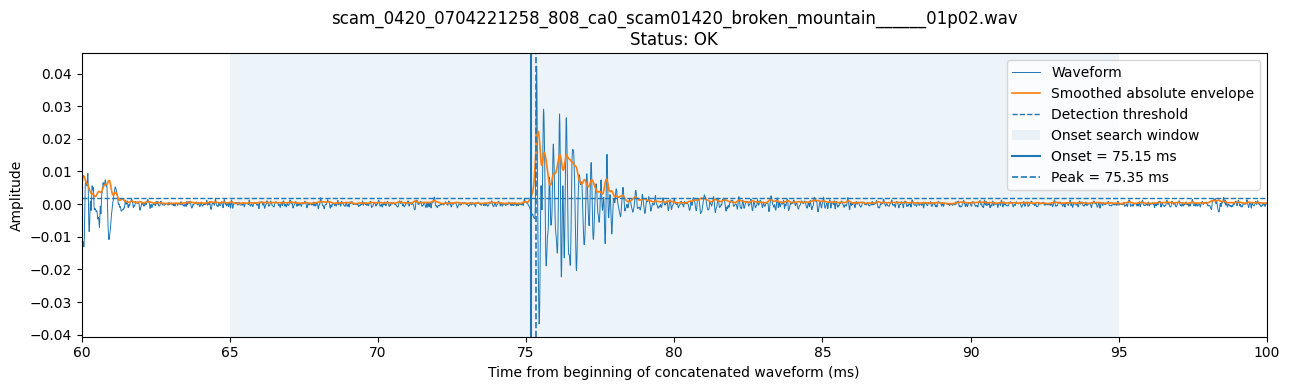

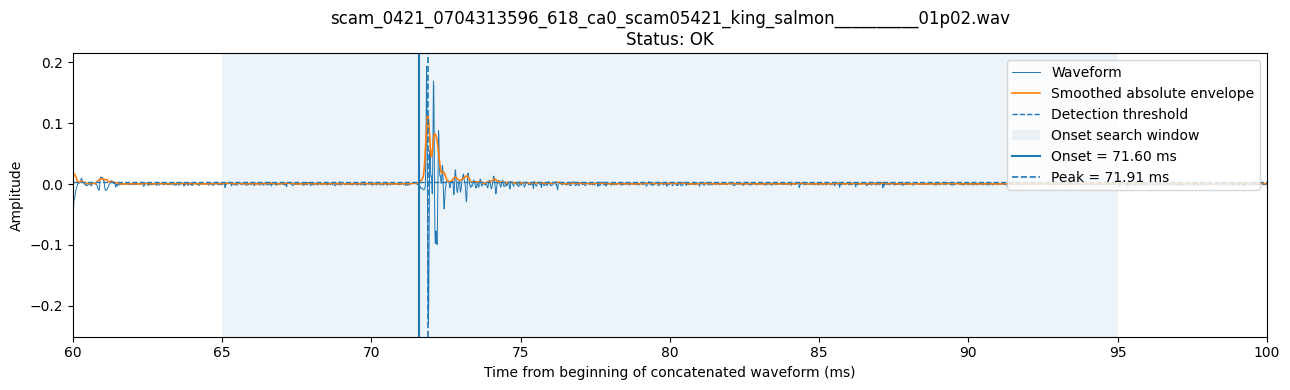

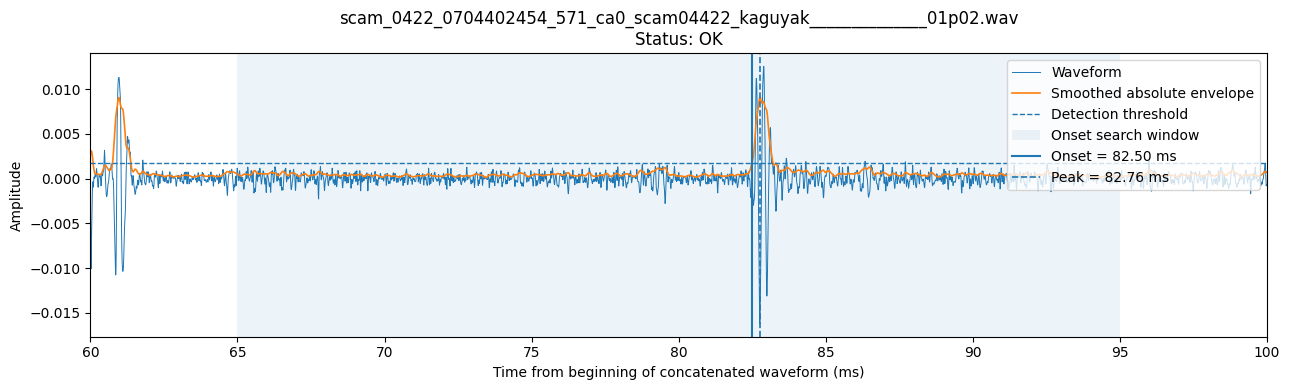

,File,Status,Onset (s),Onset (ms),Peak (ms),Peak-onset lag (ms),Shots,Samples
0,scam_0417_0703959189_698_ca0_scam04417_strike_...,OK,0.07823,78.23,78.46,0.23,29,174000
1,scam_0418_0704038328_265_ca0_scam02418_little_...,OK,0.07207,72.07,72.40,0.33,29,174000
2,scam_0420_0704221258_808_ca0_scam01420_broken_...,OK,0.07515,75.15,75.35,0.20,29,174000
3,scam_0421_0704313596_618_ca0_scam05421_king_sa...,OK,0.07160,71.60,71.91,0.31,29,174000
4,scam_0422_0704402454_571_ca0_scam04422_kaguyak...,OK,0.08250,82.50,82.76,0.26,29,174000



Status counts:
Status
OK    5
Name: count, dtype: int64


In [5]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.ndimage import gaussian_filter1d
from scipy.signal import find_peaks


# ============================================================
# SETTINGS
# ============================================================

WAV_FOLDER = Path(
    r"C:\Users\cmkua\Downloads\Concatenated Multishot WAVs\Delta"
)

FS_EXPECTED = 100_000
SHOT_SAMPLES = 6000
EXPECTED_SHOTS = 29

# Second shot occupies 0.060–0.120 seconds.
SECOND_SHOT_START = 0.060
SECOND_SHOT_END = 0.120

# Expected acoustic arrival within the second shot.
SEARCH_START = 0.065
SEARCH_END = 0.095

HEIGHT_SIGMA = 4.0
MIN_RUN_MS = 0.05
SMOOTH_MS = 0.05
MAX_PEAK_LAG_MS = 1.0

N_FILES = 5


# ============================================================
# ROBUST NOISE ESTIMATE
# ============================================================

def robust_sigma(x):
    """
    Robust estimate of standard deviation using MAD.
    """
    x = np.asarray(x, dtype=float)

    median = np.median(x)
    mad = np.median(np.abs(x - median))

    sigma = 1.4826 * mad

    if sigma == 0 or not np.isfinite(sigma):
        sigma = np.std(x)

    return sigma


# ============================================================
# ONSET DETECTOR
# ============================================================

def detect_second_shot_onset(
    audio,
    fs,
    search_start=SEARCH_START,
    search_end=SEARCH_END,
    height_sigma=HEIGHT_SIGMA,
    min_run_ms=MIN_RUN_MS,
    smooth_ms=SMOOTH_MS,
):
    """
    Detect the acoustic onset within the second shot.

    Returns a dictionary containing onset, peak, threshold,
    smoothed envelope, and status information.
    """

    audio = np.asarray(audio, dtype=float).reshape(-1)

    # Remove one overall DC offset only.
    audio = audio - np.median(audio)

    search_i0 = int(round(search_start * fs))
    search_i1 = int(round(search_end * fs))

    if search_i1 > len(audio):
        raise ValueError("Audio is shorter than the requested search window.")

    # Use the beginning of Shot1 as the noise baseline.
    baseline_i0 = int(round(SECOND_SHOT_START * fs))
    baseline_i1 = int(round(SEARCH_START * fs))

    baseline = audio[baseline_i0:baseline_i1]

    if len(baseline) < 10:
        raise ValueError("Baseline window is too short.")

    # Smooth the absolute waveform to form an amplitude envelope.
    smooth_samples = max(
        1,
        int(round((smooth_ms / 1000) * fs))
    )

    envelope = gaussian_filter1d(
        np.abs(audio),
        sigma=smooth_samples
    )

    baseline_envelope = envelope[baseline_i0:baseline_i1]

    noise_center = np.median(baseline_envelope)
    noise_sigma = robust_sigma(baseline_envelope)

    threshold = noise_center + height_sigma * noise_sigma

    search_envelope = envelope[search_i0:search_i1]
    above = search_envelope >= threshold

    min_run_samples = max(
        1,
        int(round((min_run_ms / 1000) * fs))
    )

    onset_local = None

    # Find the first sustained run above threshold.
    for i in range(0, len(above) - min_run_samples + 1):
        if np.all(above[i:i + min_run_samples]):
            onset_local = i
            break

    if onset_local is None:
        return {
            "status": "NO ONSET",
            "onset_sample": None,
            "onset_s": np.nan,
            "peak_sample": None,
            "peak_s": np.nan,
            "lag_ms": np.nan,
            "threshold": threshold,
            "envelope": envelope,
        }

    onset_sample = search_i0 + onset_local

    # Find a prominent waveform peak shortly after the onset.
    peak_search_end = min(
        len(audio),
        onset_sample + int(round(0.003 * fs))
    )

    peak_region = np.abs(audio[onset_sample:peak_search_end])

    peaks, properties = find_peaks(
        peak_region,
        height=np.max(peak_region) * 0.25
    )

    if len(peaks) == 0:
        peak_local = int(np.argmax(peak_region))
    else:
        # Use the largest detected peak.
        peak_local = peaks[
            np.argmax(properties["peak_heights"])
        ]

    peak_sample = onset_sample + peak_local

    onset_s = onset_sample / fs
    peak_s = peak_sample / fs
    lag_ms = (peak_sample - onset_sample) / fs * 1000

    if lag_ms > MAX_PEAK_LAG_MS:
        status = "LONG PEAK-ONSET LAG"
    else:
        status = "OK"

    return {
        "status": status,
        "onset_sample": onset_sample,
        "onset_s": onset_s,
        "peak_sample": peak_sample,
        "peak_s": peak_s,
        "lag_ms": lag_ms,
        "threshold": threshold,
        "envelope": envelope,
    }


# ============================================================
# SELECT FIVE 29-SHOT FILES
# ============================================================

selected_files = []

for wav_path in sorted(WAV_FOLDER.glob("*.wav")):
    fs, audio = wavfile.read(wav_path)

    if fs != FS_EXPECTED:
        continue

    n_shots = len(audio) // SHOT_SAMPLES

    if (
        n_shots == EXPECTED_SHOTS
        and len(audio) == EXPECTED_SHOTS * SHOT_SAMPLES
    ):
        selected_files.append(wav_path)

    if len(selected_files) == N_FILES:
        break


print(f"Selected {len(selected_files)} standard 29-shot files.")


# ============================================================
# RUN DETECTOR AND PLOT
# ============================================================

results = []

for wav_path in selected_files:

    fs, audio = wavfile.read(wav_path)
    audio = np.asarray(audio, dtype=float)

    result = detect_second_shot_onset(audio, fs)

    results.append({
        "File": wav_path.name,
        "Status": result["status"],
        "Onset (s)": result["onset_s"],
        "Onset (ms)": result["onset_s"] * 1000
            if np.isfinite(result["onset_s"]) else np.nan,
        "Peak (ms)": result["peak_s"] * 1000
            if np.isfinite(result["peak_s"]) else np.nan,
        "Peak-onset lag (ms)": result["lag_ms"],
        "Shots": len(audio) // SHOT_SAMPLES,
        "Samples": len(audio),
    })

    # Plot only the second-shot region.
    plot_i0 = int(SECOND_SHOT_START * fs)
    plot_i1 = int(0.100 * fs)

    t_ms = (
        np.arange(plot_i0, plot_i1) / fs
    ) * 1000

    plt.figure(figsize=(13, 4))

    plt.plot(
        t_ms,
        audio[plot_i0:plot_i1],
        linewidth=0.7,
        label="Waveform"
    )

    plt.plot(
        t_ms,
        result["envelope"][plot_i0:plot_i1],
        linewidth=1.2,
        label="Smoothed absolute envelope"
    )

    plt.axhline(
        result["threshold"],
        linestyle="--",
        linewidth=1,
        label="Detection threshold"
    )

    plt.axvspan(
        SEARCH_START * 1000,
        SEARCH_END * 1000,
        alpha=0.08,
        label="Onset search window"
    )

    if result["onset_sample"] is not None:
        plt.axvline(
            result["onset_s"] * 1000,
            linewidth=1.5,
            label=f"Onset = {result['onset_s'] * 1000:.2f} ms"
        )

        plt.axvline(
            result["peak_s"] * 1000,
            linestyle="--",
            linewidth=1.2,
            label=f"Peak = {result['peak_s'] * 1000:.2f} ms"
        )

    plt.title(
        f"{wav_path.name}\n"
        f"Status: {result['status']}"
    )
    plt.xlabel("Time from beginning of concatenated waveform (ms)")
    plt.ylabel("Amplitude")
    plt.xlim(SECOND_SHOT_START * 1000, 100)
    plt.legend(loc="upper right")
    plt.tight_layout()
    plt.show()


# ============================================================
# SUMMARY TABLE
# ============================================================

results_df = pd.DataFrame(results)

display(results_df)

print("\nStatus counts:")
print(results_df["Status"].value_counts(dropna=False))

In [14]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.io import wavfile
from scipy.stats import linregress
from scipy.signal import find_peaks, windows


# ============================================================
# FOLDERS
# ============================================================

root_folder = Path(
    r"C:\Users\cmkua\Downloads\Concatenated Multishot WAVs"
)

unit_folders = {
    "Delta": root_folder / "Delta",
    "Upper Fan": root_folder / "Upper Fan",
}

output_folder = root_folder / "LIBS Acoustic Results"
output_folder.mkdir(parents=True, exist_ok=True)

flagged_plot_folder = output_folder / "Flagged Detection Plots"
flagged_plot_folder.mkdir(parents=True, exist_ok=True)


# ============================================================
# GENERAL SETTINGS
# ============================================================

show_all_detection_plots = False
save_flagged_detection_plots = True

expected_sample_rate = 100_000
shot_samples = 6000
shot_duration = shot_samples / expected_sample_rate

# Concatenated WAV structure:
#
# Shot0: 0.000–0.060 s
# Shot1: 0.060–0.120 s  <- analyze this shot
# Shot2: 0.120–0.180 s
#
second_shot_start = 0.060
expected_shot_time = 0.074
next_shot_start = 0.120

response_window = 0.010

fit_db_top = -7
fit_db_bottom = -15

t_c = 0.002


# ============================================================
# ONSET-DETECTION SETTINGS
# Same settings as crater-floor pipeline
# ============================================================

search_half_width = 0.005
noise_window = 0.003

smooth_window_s = 0.00005
threshold_sigma = 4

min_peak_distance_s = 0.010
prominence_sigma = 3
height_sigma = 4

backtrack_window_s = 0.003
backtrack_noise_s = 0.005
backtrack_sigma = 4

min_run_s = 0.00005

# Same crater-floor review threshold
flag_lag_ms = 0.4


# ============================================================
# FFT SETTINGS
# ============================================================

usable_band = (1000, 50000)
low_band = (1000, 10000)
high_band = (10000, 30000)


# ============================================================
# EMPTY FFT OUTPUT
# ============================================================

def empty_fft_metrics():
    return {
        "Spectral Centroid (Hz)": np.nan,
        "Spectral Bandwidth (Hz)": np.nan,
        "Peak Frequency (Hz)": np.nan,
        "Rolloff 85% (Hz)": np.nan,
        "Low Power 1-10 kHz": np.nan,
        "High Power 10-30 kHz": np.nan,
        "High/Low Ratio": np.nan,
        "High Frequency Fraction": np.nan,
        "Total FFT Power": np.nan,
    }


# ============================================================
# FFT METRICS
# ============================================================

def compute_fft_metrics(segment, fs):
    """
    Compute the same frequency-domain metrics used in the
    crater-floor pipeline.
    """

    segment = np.asarray(segment, dtype=np.float64)

    if len(segment) < 2:
        return empty_fft_metrics()

    segment = segment - np.mean(segment)

    hann = windows.hann(len(segment))
    seg_w = segment * hann

    freqs = np.fft.rfftfreq(
        len(seg_w),
        d=1 / fs,
    )

    X = np.fft.rfft(seg_w)
    power = np.abs(X) ** 2

    usable_mask = (
        (freqs >= usable_band[0])
        & (freqs <= usable_band[1])
    )

    f = freqs[usable_mask]
    p = power[usable_mask]

    if len(p) == 0 or np.sum(p) <= 0:
        return empty_fft_metrics()

    p_sum = np.sum(p)

    centroid = np.sum(f * p) / p_sum

    bandwidth = np.sqrt(
        np.sum(
            ((f - centroid) ** 2) * p
        ) / p_sum
    )

    peak_freq = f[np.argmax(p)]

    cumulative = np.cumsum(p)

    rolloff_candidates = np.where(
        cumulative >= 0.85 * p_sum
    )[0]

    if len(rolloff_candidates) > 0:
        rolloff_85 = f[rolloff_candidates[0]]
    else:
        rolloff_85 = np.nan

    low_mask = (
        (freqs >= low_band[0])
        & (freqs < low_band[1])
    )

    high_mask = (
        (freqs >= high_band[0])
        & (freqs < high_band[1])
    )

    low_power = np.sum(power[low_mask])
    high_power = np.sum(power[high_mask])
    total_power = np.sum(power)

    if low_power > 0:
        high_low_ratio = high_power / low_power
    else:
        high_low_ratio = np.nan

    if total_power > 0:
        high_freq_fraction = high_power / total_power
    else:
        high_freq_fraction = np.nan

    return {
        "Spectral Centroid (Hz)": centroid,
        "Spectral Bandwidth (Hz)": bandwidth,
        "Peak Frequency (Hz)": peak_freq,
        "Rolloff 85% (Hz)": rolloff_85,
        "Low Power 1-10 kHz": low_power,
        "High Power 10-30 kHz": high_power,
        "High/Low Ratio": high_low_ratio,
        "High Frequency Fraction": high_freq_fraction,
        "Total FFT Power": total_power,
    }


# ============================================================
# LOAD WAV
# ============================================================

def load_wav_mono(wav_path):
    """
    Load a WAV file and convert it to mono float64.
    """

    fs, x = wavfile.read(wav_path)

    x = np.asarray(x)

    if x.ndim > 1:
        x = x.astype(np.float64).mean(axis=1)
    else:
        x = x.astype(np.float64)

    return fs, x.reshape(-1)


# ============================================================
# PROCESS ONE WAV
# ============================================================

def process_one_wav(wav_path, unit):
    """
    Run the original crater-floor onset and metric pipeline
    on Shot1 of one concatenated WAV.
    """

    fs, x = load_wav_mono(wav_path)

    total_samples = len(x)
    duration_s = total_samples / fs

    if fs != expected_sample_rate:
        raise ValueError(
            f"Expected {expected_sample_rate} Hz, "
            f"but found {fs} Hz."
        )

    if total_samples % shot_samples != 0:
        raise ValueError(
            f"{total_samples} samples is not divisible "
            f"by {shot_samples} samples per shot."
        )

    number_of_shots = total_samples // shot_samples

    if number_of_shots < 2:
        raise ValueError(
            "Recording contains fewer than two shots."
        )

    # Same preprocessing as crater-floor pipeline.
    x = x - np.mean(x)

    abs_x = np.abs(x)

    smooth_n = max(
        1,
        int(round(smooth_window_s * fs)),
    )

    kernel = np.ones(smooth_n) / smooth_n

    env = np.convolve(
        abs_x,
        kernel,
        mode="same",
    )

    # --------------------------------------------------------
    # EXPECTED-ONSET SEARCH REGION
    # --------------------------------------------------------

    search_start = (
        expected_shot_time
        - search_half_width
    )

    search_end = (
        expected_shot_time
        + search_half_width
    )

    isearch0 = max(
        0,
        int(round(search_start * fs)),
    )

    isearch1 = min(
        len(x),
        int(round(search_end * fs)),
    )

    # Baseline immediately before the search region.
    inoise1 = isearch0

    inoise0 = max(
        0,
        int(
            round(
                (search_start - noise_window) * fs
            )
        ),
    )

    noise_env = env[inoise0:inoise1]

    if len(noise_env) == 0:
        raise ValueError(
            "Noise window contains no samples."
        )

    noise_mean = np.mean(noise_env)
    noise_std = np.std(noise_env)

    threshold = (
        noise_mean
        + threshold_sigma * noise_std
    )

    search_env = env[isearch0:isearch1]

    min_peak_distance = max(
        1,
        int(round(min_peak_distance_s * fs)),
    )

    min_prominence = (
        prominence_sigma * noise_std
    )

    min_height = (
        noise_mean
        + height_sigma * noise_std
    )

    peaks, props = find_peaks(
        search_env,
        height=min_height,
        prominence=min_prominence,
        distance=min_peak_distance,
    )

    found_peak = len(peaks) > 0

    flagged = False
    flag_reason = ""
    lag_ms = np.nan

    onset_index = None
    peak_index = None

    response_start = np.nan
    response_stop = np.nan
    peak_time = np.nan
    onset_threshold = np.nan

    slope = np.nan
    intercept = np.nan
    r_value = np.nan
    drop_time = np.nan
    C2 = np.nan

    segment = None
    segment_t = None
    edc_db = None
    fit_mask = None
    fit_line = None

    fft_metrics = empty_fft_metrics()

    # --------------------------------------------------------
    # PEAK FOUND
    # --------------------------------------------------------

    if found_peak:
        # Same crater-floor rule: use first qualifying peak.
        best_peak_local = peaks[0]

        peak_index = (
            isearch0
            + best_peak_local
        )

        peak_time = peak_index / fs

        # ----------------------------------------------------
        # BACKTRACK FROM PEAK TO ONSET
        # ----------------------------------------------------

        backtrack_samples = int(
            round(backtrack_window_s * fs)
        )

        second_shot_start_index = int(
            round(second_shot_start * fs)
        )

        back_start = max(
            second_shot_start_index,
            peak_index - backtrack_samples,
        )

        backtrack_noise_samples = int(
            round(backtrack_noise_s * fs)
        )

        noise_back_start = max(
            0,
            back_start - backtrack_noise_samples,
        )

        noise_back_end = back_start

        local_noise = env[
            noise_back_start:noise_back_end
        ]

        if len(local_noise) > 0:
            local_noise_mean = np.mean(
                local_noise
            )

            local_noise_std = np.std(
                local_noise
            )

            onset_threshold = (
                local_noise_mean
                + backtrack_sigma
                * local_noise_std
            )

        else:
            onset_threshold = threshold

        search_back_env = env[
            back_start:peak_index
        ]

        above = (
            search_back_env
            > onset_threshold
        )

        min_run_samples = max(
            1,
            int(round(min_run_s * fs)),
        )

        for i in range(
            len(above)
            - min_run_samples
            + 1
        ):
            if np.all(
                above[
                    i:i + min_run_samples
                ]
            ):
                onset_index = back_start + i
                break

        # Same behavior as original code:
        # use peak as onset but flag the file.
        if onset_index is None:
            onset_index = peak_index
            flagged = True
            flag_reason = (
                "NO CLEAN ONSET BEFORE PEAK"
            )

        response_start = onset_index / fs

        response_stop = (
            response_start
            + response_window
        )

        lag_ms = (
            peak_index - onset_index
        ) / fs * 1000

        if lag_ms > flag_lag_ms:
            flagged = True

            if flag_reason:
                flag_reason += (
                    " | LONG PEAK-ONSET LAG"
                )
            else:
                flag_reason = (
                    "LONG PEAK-ONSET LAG"
                )

        # Prevent response window from entering Shot2.
        if response_stop > next_shot_start:
            response_stop = next_shot_start

            flagged = True

            if flag_reason:
                flag_reason += (
                    " | WINDOW TRUNCATED"
                )
            else:
                flag_reason = (
                    "WINDOW TRUNCATED"
                )

        # ----------------------------------------------------
        # EXTRACT RESPONSE SEGMENT
        # ----------------------------------------------------

        i0 = onset_index

        i1 = min(
            len(x),
            int(round(response_stop * fs)),
        )

        segment = x[i0:i1]

        segment_t = (
            np.arange(len(segment)) / fs
        )

        # ----------------------------------------------------
        # ENERGY DECAY CURVE
        # ----------------------------------------------------

        if len(segment) > 1:
            energy = segment ** 2

            edc = np.cumsum(
                energy[::-1]
            )[::-1]

            edc_max = np.max(edc)

            if edc_max > 0:
                edc_norm = edc / edc_max

                edc_db = 10 * np.log10(
                    edc_norm + 1e-20
                )

                fit_mask = (
                    (edc_db <= fit_db_top)
                    & (edc_db >= fit_db_bottom)
                )

                if np.sum(fit_mask) >= 2:
                    (
                        slope,
                        intercept,
                        r_value,
                        p_value,
                        std_err,
                    ) = linregress(
                        segment_t[fit_mask],
                        edc_db[fit_mask],
                    )

                    fit_line = (
                        slope * segment_t
                        + intercept
                    )

                    db_drop = abs(
                        fit_db_bottom
                        - fit_db_top
                    )

                    if slope != 0:
                        drop_time = (
                            db_drop
                            / abs(slope)
                        )

                else:
                    fit_line = np.full_like(
                        edc_db,
                        np.nan,
                    )

                # --------------------------------------------
                # C2
                # --------------------------------------------

                i_c = int(round(t_c * fs))

                i_c = min(
                    i_c,
                    len(energy),
                )

                early_energy = np.sum(
                    energy[:i_c]
                )

                late_energy = np.sum(
                    energy[i_c:]
                )

                if (
                    early_energy > 0
                    and late_energy > 0
                ):
                    C2 = 10 * np.log10(
                        early_energy
                        / late_energy
                    )

            # ------------------------------------------------
            # FFT METRICS
            # ------------------------------------------------

            fft_metrics = compute_fft_metrics(
                segment,
                fs,
            )

    # --------------------------------------------------------
    # NO PEAK FOUND
    # --------------------------------------------------------

    else:
        flagged = True
        flag_reason = "NO PEAK"

    if not flagged:
        status = "OK"
    else:
        status = flag_reason

    row = {
        "Unit": unit,
        "File Name": wav_path.name,
        "Path": str(wav_path),

        "Status": status,
        "Flagged": flagged,

        "Sample Rate (Hz)": fs,
        "Samples": total_samples,
        "Duration (s)": duration_s,
        "Number of Shots": number_of_shots,
        "Observation Type":
            f"{number_of_shots}-shot",

        "Search Start (s)": search_start,
        "Search End (s)": search_end,

        "Onset Sample": (
            onset_index
            if onset_index is not None
            else np.nan
        ),

        "Onset (s)": response_start,

        "Onset Within Shot1 (ms)": (
            (
                response_start
                - second_shot_start
            ) * 1000
            if np.isfinite(response_start)
            else np.nan
        ),

        "Peak Sample": (
            peak_index
            if peak_index is not None
            else np.nan
        ),

        "Peak Time (s)": peak_time,
        "Peak-Onset Lag (ms)": lag_ms,

        "Response Stop (s)": response_stop,
        "Response Duration (ms)": (
            (
                response_stop
                - response_start
            ) * 1000
            if (
                np.isfinite(response_start)
                and np.isfinite(response_stop)
            )
            else np.nan
        ),

        "Slope (dB/s)": slope,

        "Decay Rate (-Slope) (dB/s)": (
            -slope
            if np.isfinite(slope)
            else np.nan
        ),

        "R^2": (
            r_value ** 2
            if np.isfinite(r_value)
            else np.nan
        ),

        "Drop Time (s)": drop_time,
        "C2 (dB)": C2,

        **fft_metrics,
    }

    plot_data = {
        "x": x,
        "env": env,
        "fs": fs,

        "search_start": search_start,
        "search_end": search_end,
        "isearch0": isearch0,
        "isearch1": isearch1,
        "back_start": (
            back_start
            if found_peak
            else isearch0
        ),

        "threshold": threshold,
        "onset_threshold": onset_threshold,

        "found_peak": found_peak,
        "onset_index": onset_index,
        "peak_index": peak_index,

        "segment_t": segment_t,
        "edc_db": edc_db,
        "fit_mask": fit_mask,
        "fit_line": fit_line,
    }

    return row, plot_data


# ============================================================
# DETECTION PLOT
# ============================================================

def make_detection_plot(
    wav_path,
    unit,
    row,
    plot_data,
    save_path=None,
):
    """
    Create the same three-part review plot:
    waveform, envelope, and EDC.
    """

    x = plot_data["x"]
    env = plot_data["env"]
    fs = plot_data["fs"]

    isearch0 = plot_data["isearch0"]
    isearch1 = plot_data["isearch1"]
    back_start = plot_data["back_start"]

    search_start = plot_data["search_start"]
    search_end = plot_data["search_end"]

    threshold = plot_data["threshold"]
    onset_threshold = plot_data[
        "onset_threshold"
    ]

    found_peak = plot_data["found_peak"]
    onset_index = plot_data["onset_index"]
    peak_index = plot_data["peak_index"]

    segment_t = plot_data["segment_t"]
    edc_db = plot_data["edc_db"]
    fit_mask = plot_data["fit_mask"]
    fit_line = plot_data["fit_line"]

    full_t = np.arange(len(x)) / fs

    # Show the full possible onset-backtracking region in QA plots,
    # not only the narrower peak-search window.
    iplot0 = min(back_start, isearch0)
    iplot1 = isearch1

    fig, axes = plt.subplots(
        3,
        1,
        figsize=(11, 9),
    )

    # --------------------------------------------------------
    # WAVEFORM
    # --------------------------------------------------------

    axes[0].plot(
        full_t[iplot0:iplot1],
        x[iplot0:iplot1],
        linewidth=0.8,
    )

    if onset_index is not None:
        axes[0].axvline(
            onset_index / fs,
            linestyle="--",
            label="Onset",
        )

    if peak_index is not None:
        axes[0].axvline(
            peak_index / fs,
            linestyle=":",
            label="Peak",
        )

    axes[0].axvline(
        search_start,
        linestyle="-.",
        linewidth=0.8,
        label="Peak search start",
    )

    axes[0].axvline(
        search_end,
        linestyle="-.",
        linewidth=0.8,
        label="Peak search end",
    )

    axes[0].set_title(
        "Waveform: Backtracking + Peak-Search Region"
    )

    axes[0].set_xlabel("Time (s)")
    axes[0].set_ylabel("Amplitude")

    if onset_index is not None:
        axes[0].legend()

    # --------------------------------------------------------
    # ENVELOPE
    # --------------------------------------------------------

    axes[1].plot(
        full_t[iplot0:iplot1],
        env[iplot0:iplot1],
        linewidth=0.9,
        label="Smoothed envelope",
    )

    axes[1].axhline(
        threshold,
        linestyle=":",
        label="Peak threshold",
    )

    if np.isfinite(onset_threshold):
        axes[1].axhline(
            onset_threshold,
            linestyle="--",
            label="Onset threshold",
        )

    if onset_index is not None:
        axes[1].axvline(
            onset_index / fs,
            linestyle="--",
        )

    if peak_index is not None:
        axes[1].axvline(
            peak_index / fs,
            linestyle=":",
        )

    axes[1].axvline(
        search_start,
        linestyle="-.",
        linewidth=0.8,
        label="Peak search start",
    )

    axes[1].axvline(
        search_end,
        linestyle="-.",
        linewidth=0.8,
        label="Peak search end",
    )

    axes[1].set_title(
        "Smoothed Envelope: Backtracking + Peak Search"
    )

    axes[1].set_xlabel("Time (s)")
    axes[1].set_ylabel("Envelope")
    axes[1].legend()

    # --------------------------------------------------------
    # EDC
    # --------------------------------------------------------

    if (
        found_peak
        and segment_t is not None
        and edc_db is not None
    ):
        axes[2].plot(
            segment_t,
            edc_db,
            label="EDC",
        )

        if (
            fit_mask is not None
            and np.sum(fit_mask) >= 2
        ):
            axes[2].plot(
                segment_t,
                fit_line,
                "--",
                label="-7 to -15 dB fit",
            )

        axes[2].axhline(
            fit_db_top,
            linestyle=":",
            linewidth=0.8,
        )

        axes[2].axhline(
            fit_db_bottom,
            linestyle=":",
            linewidth=0.8,
        )

        axes[2].set_title(
            "Energy Decay Curve"
        )

        axes[2].set_xlabel(
            "Time after onset (s)"
        )

        axes[2].set_ylabel("EDC (dB)")
        axes[2].legend()

    else:
        axes[2].text(
            0.5,
            0.5,
            "No onset detected",
            horizontalalignment="center",
            verticalalignment="center",
            transform=axes[2].transAxes,
        )

        axes[2].set_title(
            "Energy Decay Curve"
        )

    fig.suptitle(
        f"{unit} | {wav_path.name}\n"
        f"Status: {row['Status']}",
        fontsize=11,
    )

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(
            save_path,
            dpi=170,
            bbox_inches="tight",
        )

    if show_all_detection_plots:
        plt.show()
    else:
        plt.close(fig)


# ============================================================
# PROCESS ALL FILES
# ============================================================

results = []

for unit, wav_folder in unit_folders.items():
    files = sorted(
        wav_folder.glob("*.wav")
    )

    print("\n" + "=" * 90)
    print(f"{unit}: {len(files)} WAV files")
    print("=" * 90)

    for file_number, wav_path in enumerate(
        files,
        start=1,
    ):
        try:
            row, plot_data = process_one_wav(
                wav_path,
                unit,
            )

        except Exception as exc:
            row = {
                "Unit": unit,
                "File Name": wav_path.name,
                "Path": str(wav_path),
                "Status": "ERROR",
                "Flagged": True,
                "Error": str(exc),
            }

            plot_data = None

        results.append(row)

        lag = row.get(
            "Peak-Onset Lag (ms)",
            np.nan,
        )

        onset = row.get(
            "Onset (s)",
            np.nan,
        )

        if np.isfinite(onset):
            onset_text = f"{onset:.6f} s"
        else:
            onset_text = "None"

        if np.isfinite(lag):
            lag_text = f"{lag:.3f} ms"
        else:
            lag_text = "None"

        print(
            f"[{file_number:03d}/{len(files):03d}] "
            f"{row['Status']:<30} | "
            f"onset={onset_text:<12} | "
            f"lag={lag_text:<10} | "
            f"{wav_path.name}"
        )

        # Save QA plots only for flagged files.
        if (
            save_flagged_detection_plots
            and row["Flagged"]
            and plot_data is not None
        ):
            safe_status = (
                row["Status"]
                .replace(" ", "_")
                .replace("|", "_")
                .replace("/", "_")
            )

            plot_name = (
                f"{unit}_{safe_status}_"
                f"{wav_path.stem}.png"
            )

            make_detection_plot(
                wav_path=wav_path,
                unit=unit,
                row=row,
                plot_data=plot_data,
                save_path=(
                    flagged_plot_folder
                    / plot_name
                ),
            )

        elif (
            show_all_detection_plots
            and plot_data is not None
        ):
            make_detection_plot(
                wav_path=wav_path,
                unit=unit,
                row=row,
                plot_data=plot_data,
            )


# ============================================================
# EXPORT RESULTS
# ============================================================

results_df = pd.DataFrame(results)

all_results_path = (
    output_folder
    / "LIBS_acoustic_all_results.csv"
)

accepted_results_path = (
    output_folder
    / "LIBS_acoustic_accepted_results.csv"
)

flagged_results_path = (
    output_folder
    / "LIBS_acoustic_flagged_results.csv"
)

results_df.to_csv(
    all_results_path,
    index=False,
)

accepted_df = results_df[
    results_df["Flagged"] == False
].copy()

accepted_df.to_csv(
    accepted_results_path,
    index=False,
)

flagged_df = results_df[
    results_df["Flagged"] == True
].copy()

flagged_df.to_csv(
    flagged_results_path,
    index=False,
)


# Separate unit files
for unit in unit_folders:
    unit_df = results_df[
        results_df["Unit"] == unit
    ].copy()

    unit_output_path = (
        output_folder
        / f"{unit.replace(' ', '_')}_LIBS_acoustic_results.csv"
    )

    unit_df.to_csv(
        unit_output_path,
        index=False,
    )


# ============================================================
# SUMMARIES
# ============================================================

print("\n" + "=" * 90)
print("OVERALL STATUS COUNTS")
print("=" * 90)

print(
    results_df["Status"]
    .value_counts(dropna=False)
)


print("\n" + "=" * 90)
print("STATUS BY UNIT")
print("=" * 90)

print(
    pd.crosstab(
        results_df["Unit"],
        results_df["Status"],
    )
)


print("\n" + "=" * 90)
print("FLAGGED COUNTS BY UNIT")
print("=" * 90)

print(
    pd.crosstab(
        results_df["Unit"],
        results_df["Flagged"],
    )
)


print("\n" + "=" * 90)
print("ACCEPTED ONSET STATISTICS")
print("=" * 90)

if len(accepted_df) > 0:
    summary_columns = [
        "Onset (s)",
        "Onset Within Shot1 (ms)",
        "Peak-Onset Lag (ms)",
        "Slope (dB/s)",
        "R^2",
        "Drop Time (s)",
        "C2 (dB)",
        "Spectral Centroid (Hz)",
        "Spectral Bandwidth (Hz)",
        "Peak Frequency (Hz)",
        "Rolloff 85% (Hz)",
        "High/Low Ratio",
        "High Frequency Fraction",
    ]

    available_columns = [
        column
        for column in summary_columns
        if column in accepted_df.columns
    ]

    print(
        accepted_df[
            available_columns
        ]
        .describe()
        .round(4)
    )

else:
    print(
        "No files were automatically accepted."
    )


print("\n" + "=" * 90)
print("OUTPUT FILES")
print("=" * 90)

print(f"All results:      {all_results_path}")
print(f"Accepted results: {accepted_results_path}")
print(f"Flagged results:  {flagged_results_path}")
print(f"Flagged plots:    {flagged_plot_folder}")


Delta: 123 WAV files
[001/123] OK                             | onset=0.078220 s   | lag=0.310 ms   | scam_0417_0703959189_698_ca0_scam04417_strike_creek_________01p02.wav
[002/123] OK                             | onset=0.072090 s   | lag=0.310 ms   | scam_0418_0704038328_265_ca0_scam02418_little_beach_________01p02.wav
[003/123] OK                             | onset=0.075140 s   | lag=0.210 ms   | scam_0420_0704221258_808_ca0_scam01420_broken_mountain______01p02.wav
[004/123] OK                             | onset=0.071610 s   | lag=0.300 ms   | scam_0421_0704313596_618_ca0_scam05421_king_salmon__________01p02.wav
[005/123] NO PEAK                        | onset=None         | lag=None       | scam_0422_0704402454_571_ca0_scam04422_kaguyak______________01p02.wav
[006/123] LONG PEAK-ONSET LAG            | onset=0.072550 s   | lag=0.460 ms   | scam_0424_0704579883_996_ca0_scam06424_cape_gull____________01p02.wav
[007/123] NO PEAK                        | onset=None         | lag=None

Auditing 29 files.


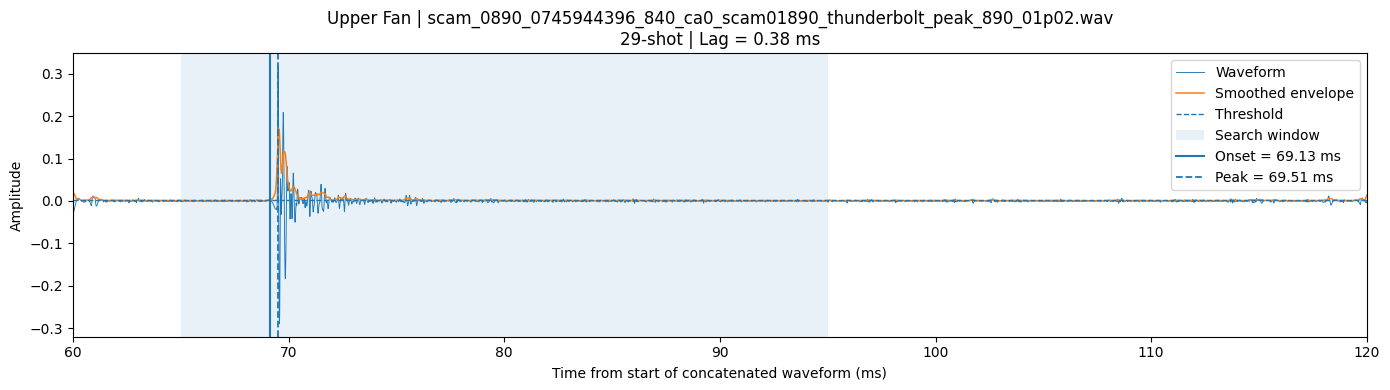

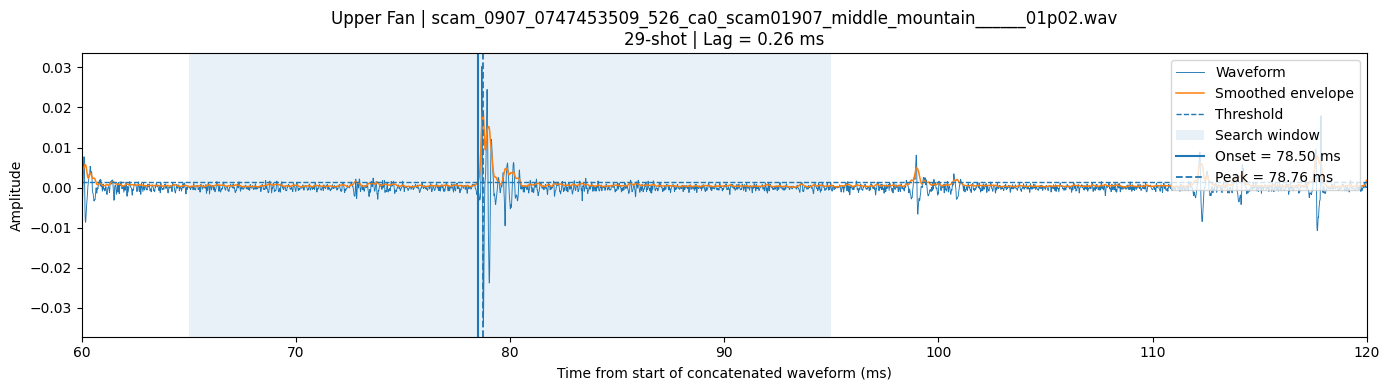

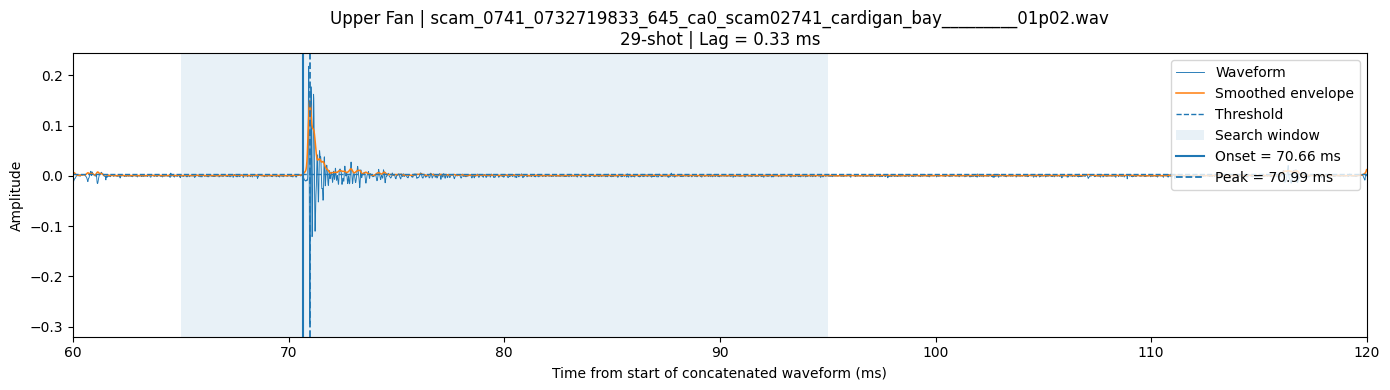

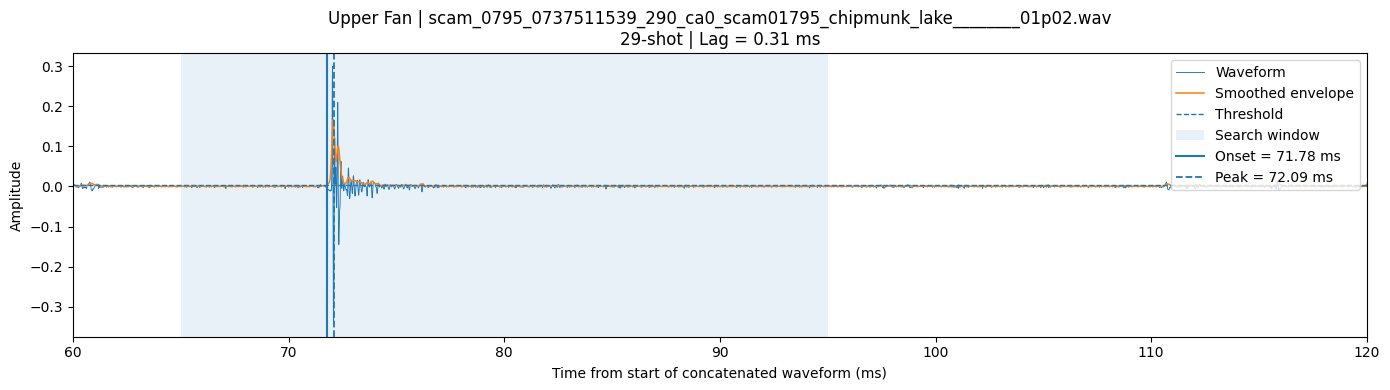

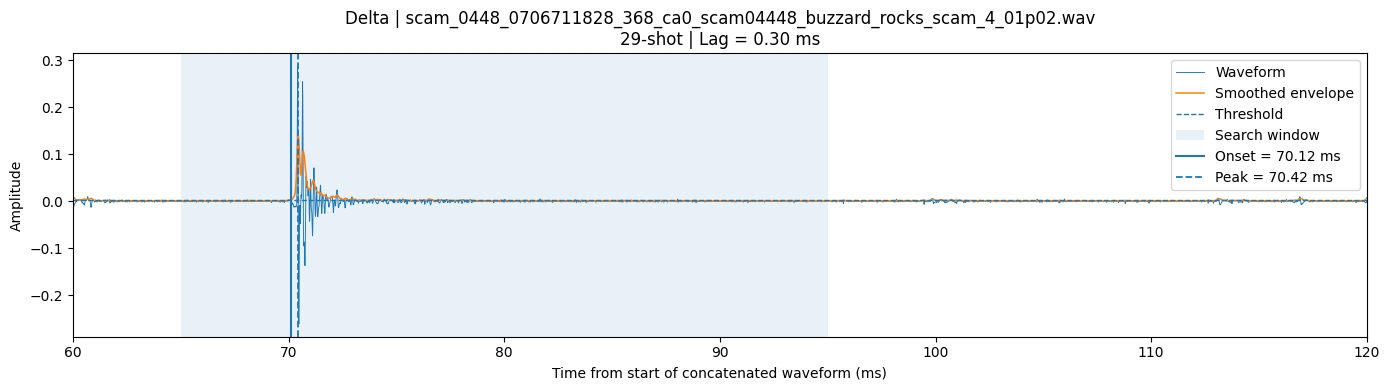

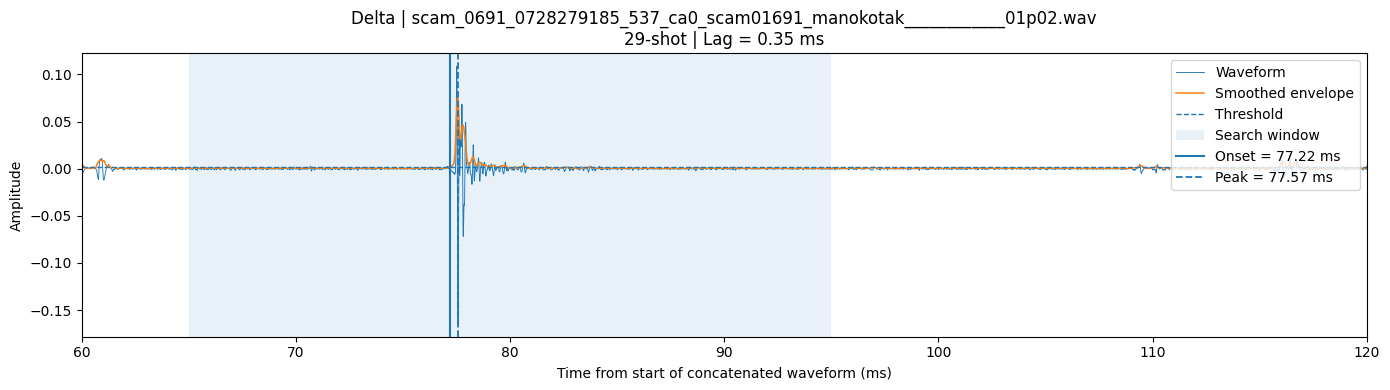

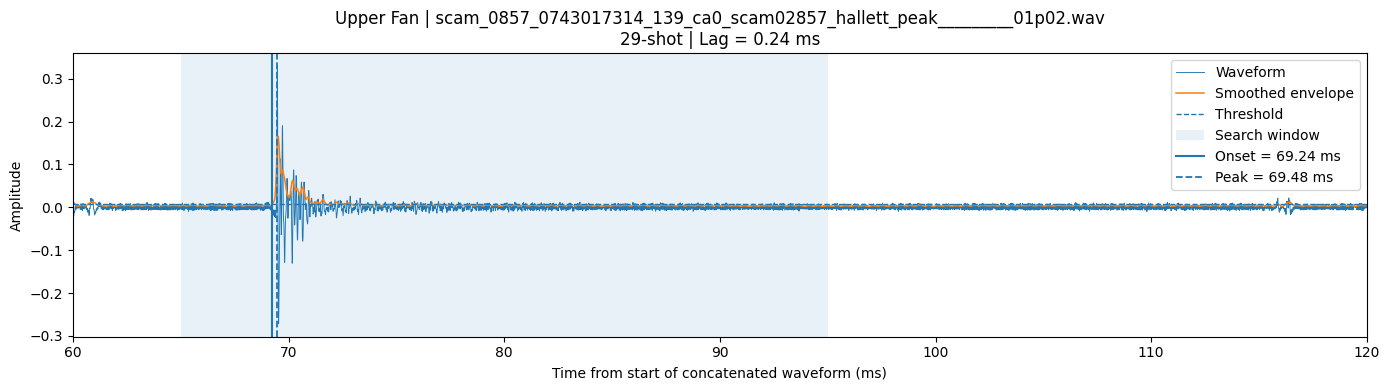

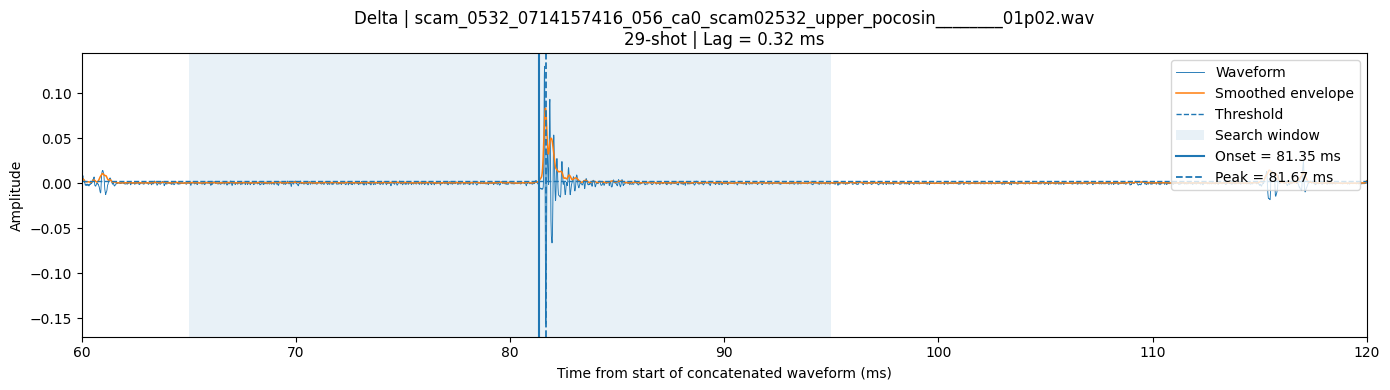

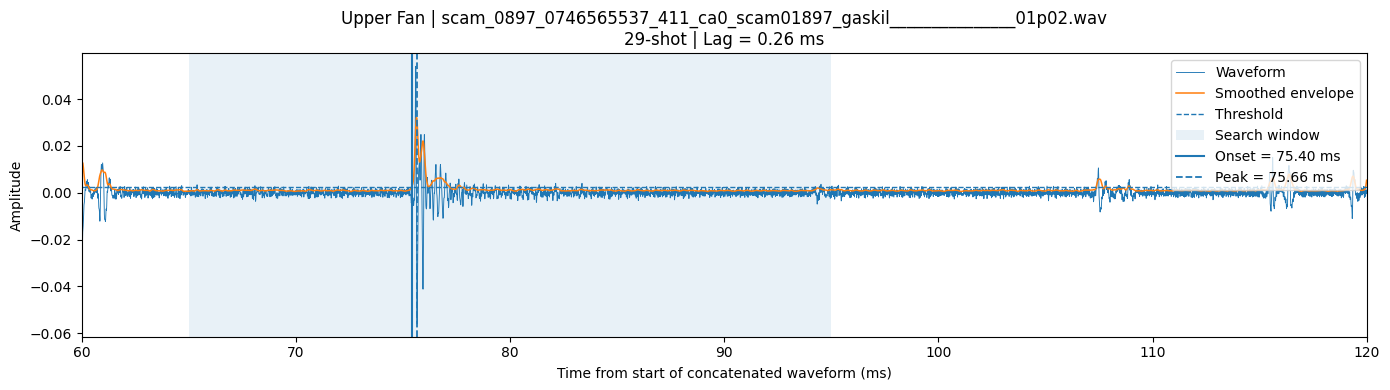

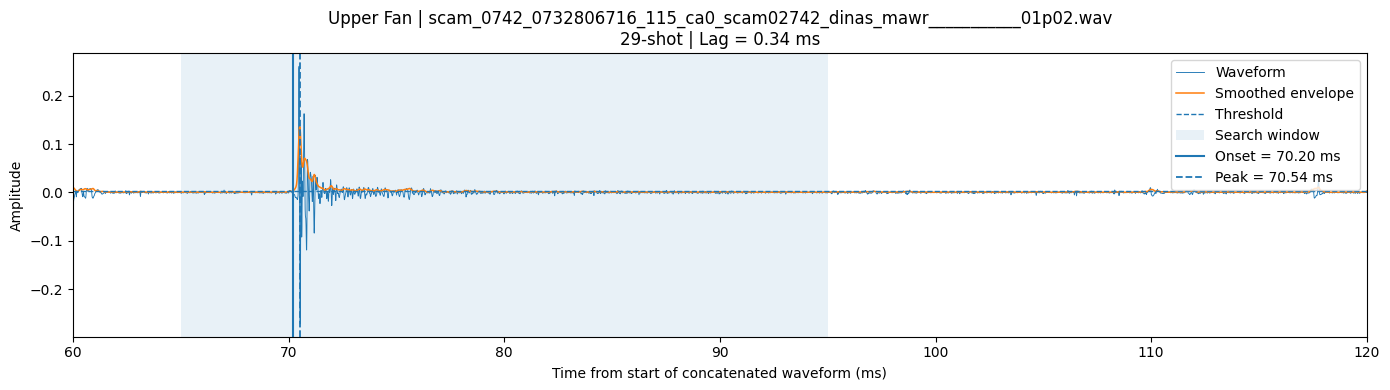

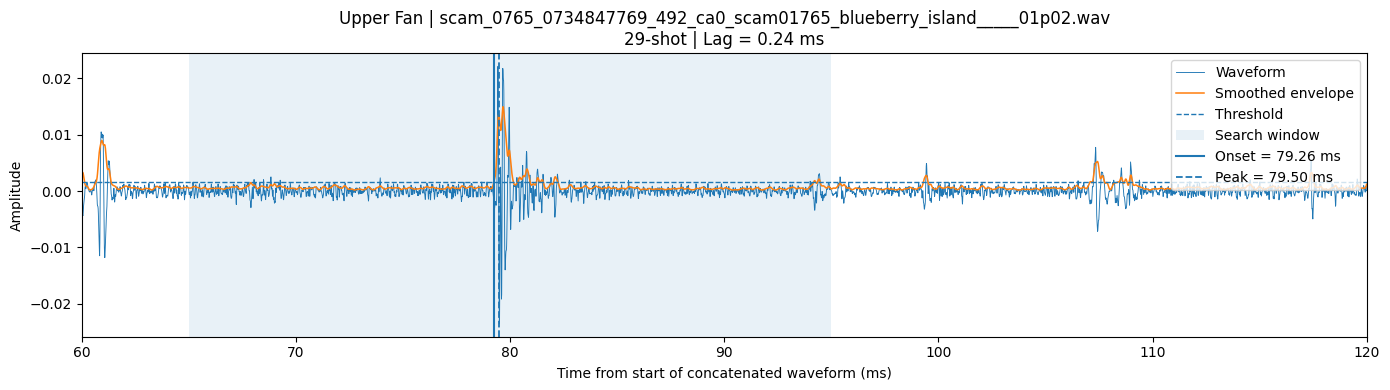

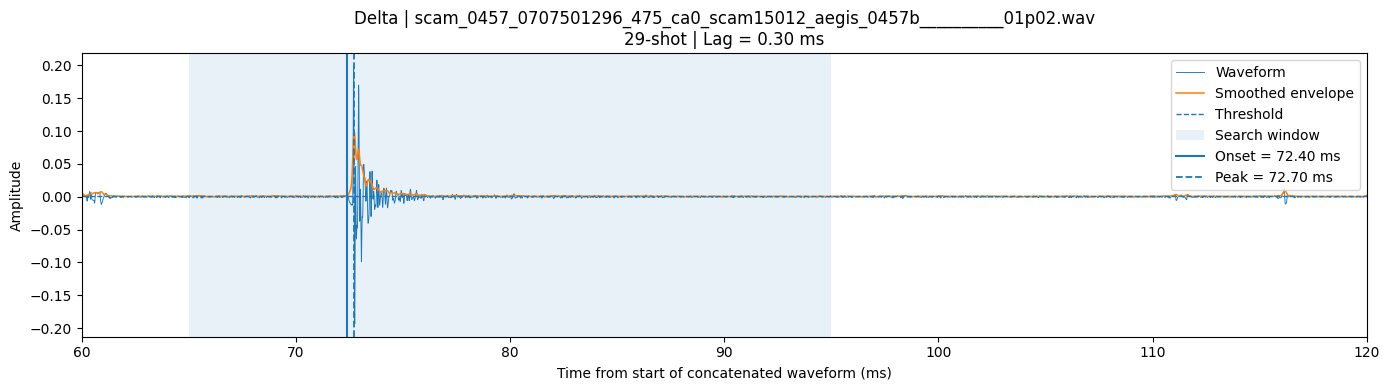

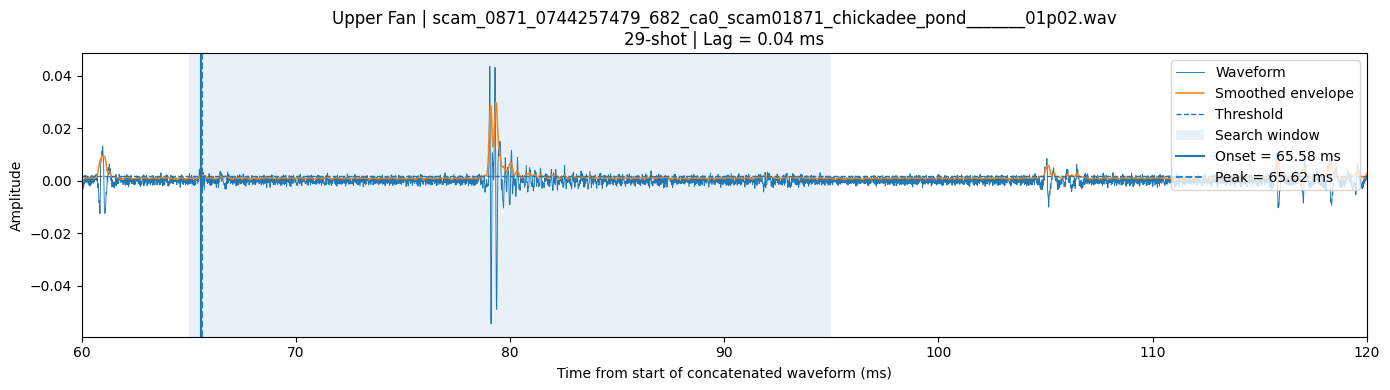

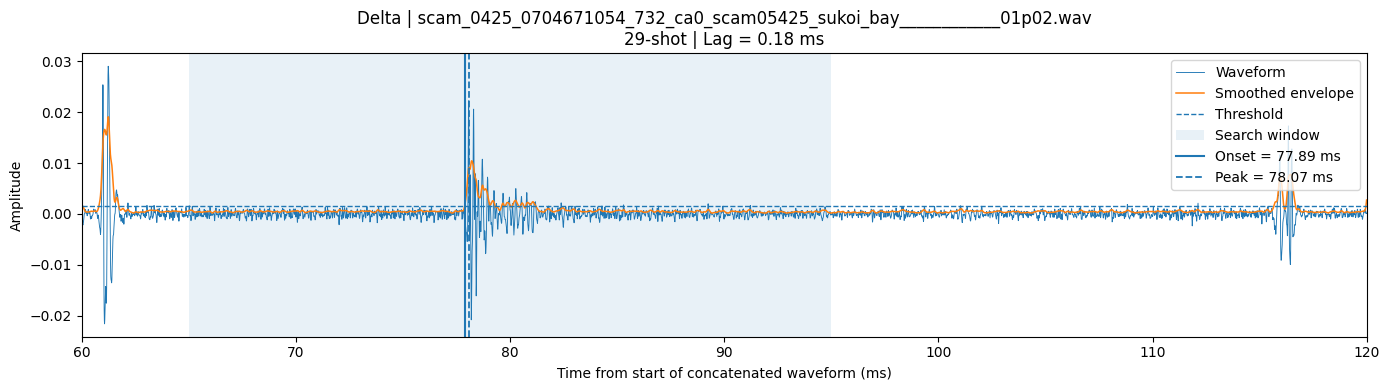

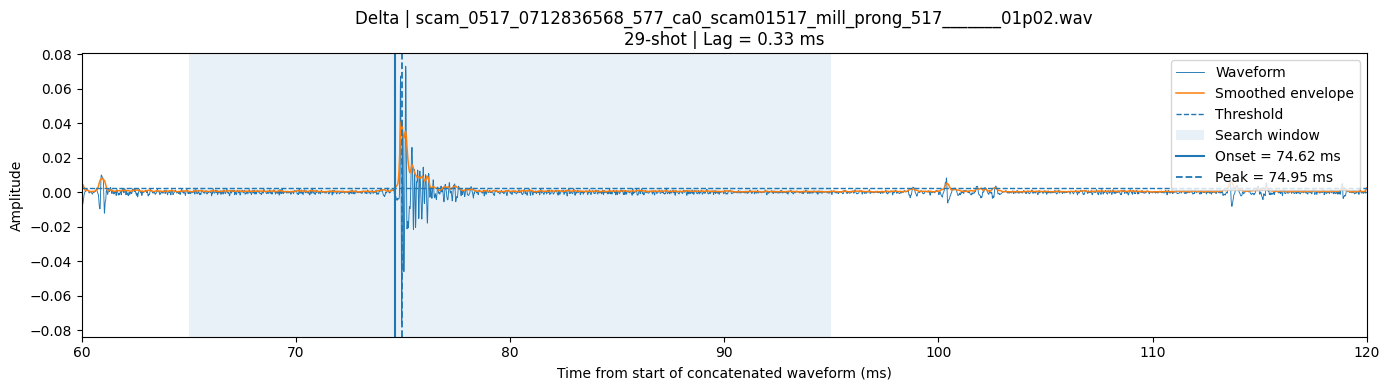

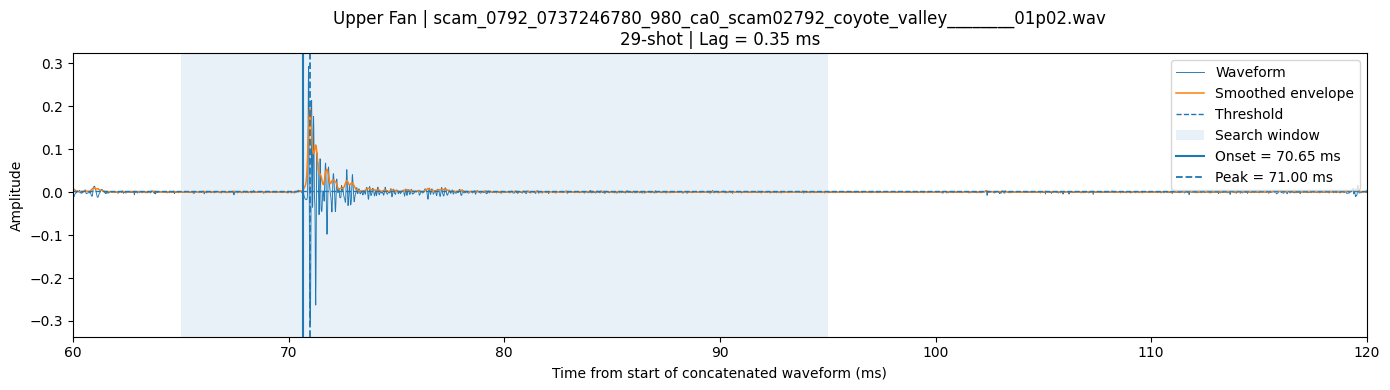

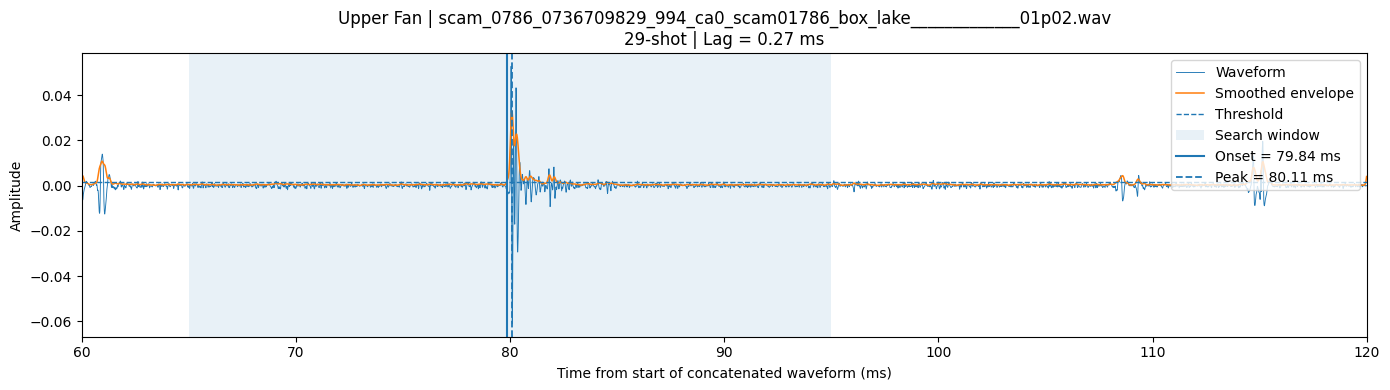

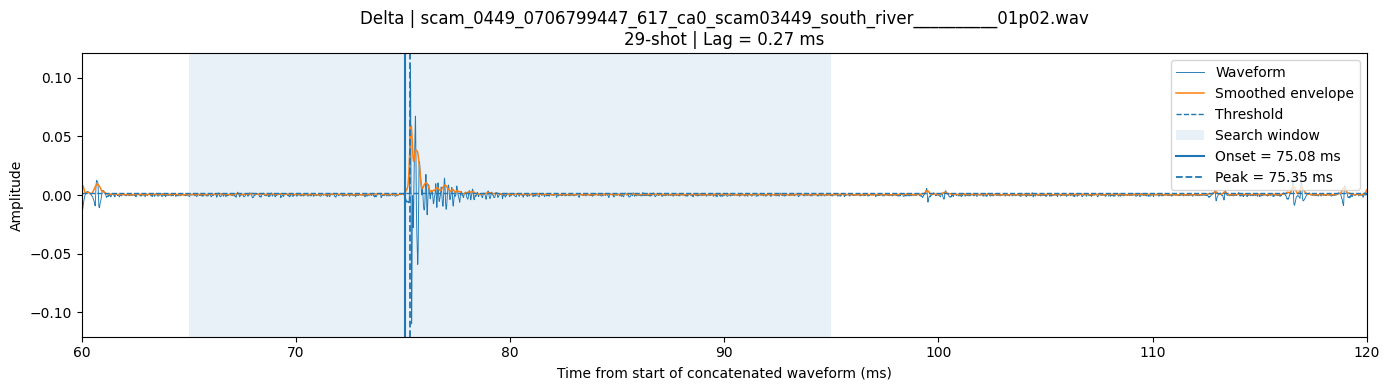

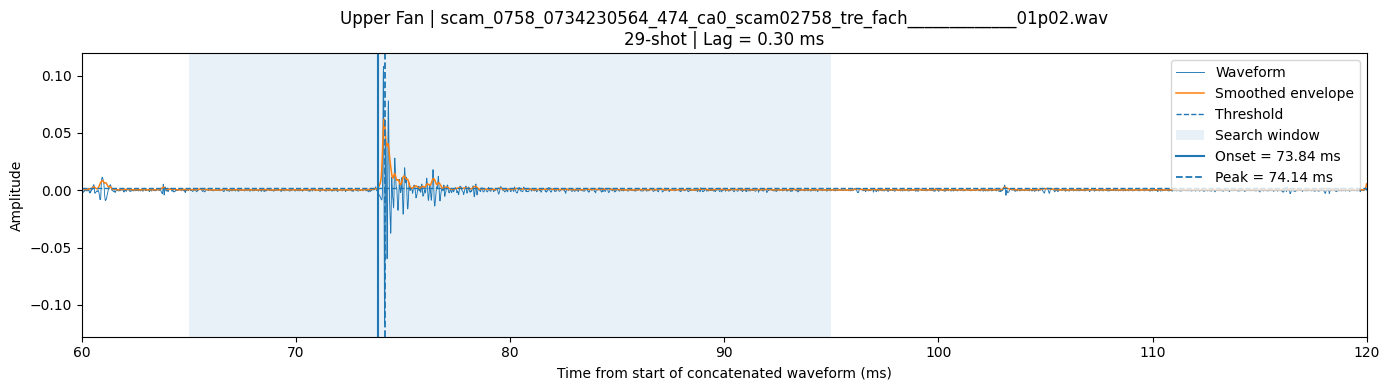

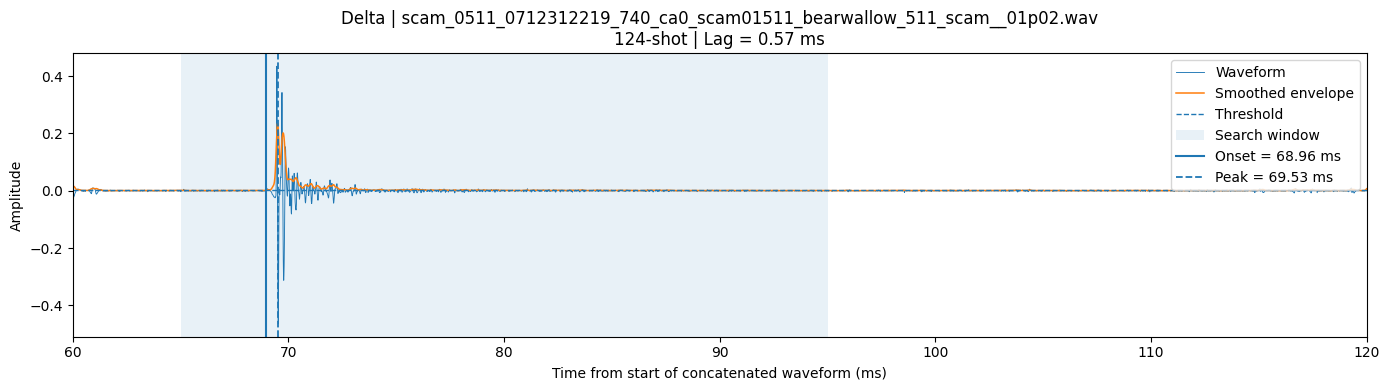

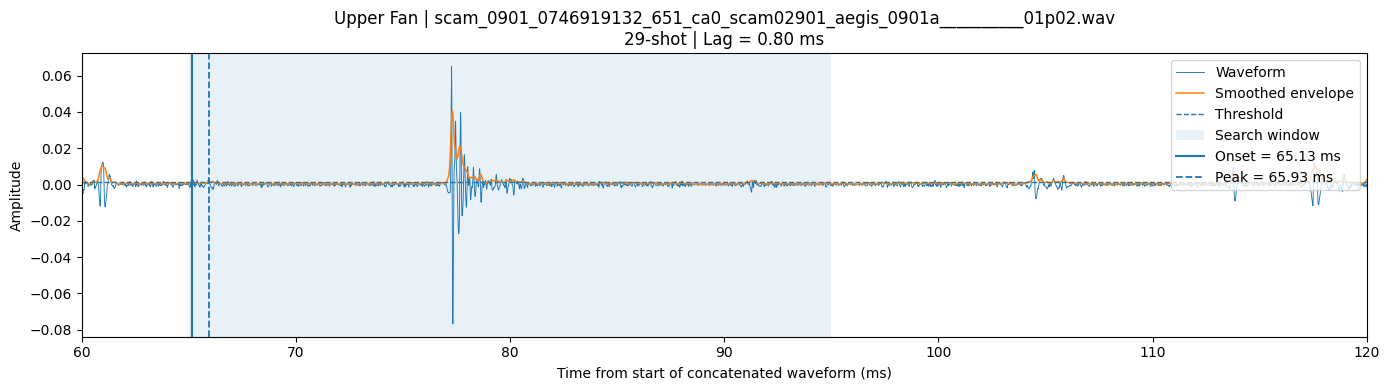

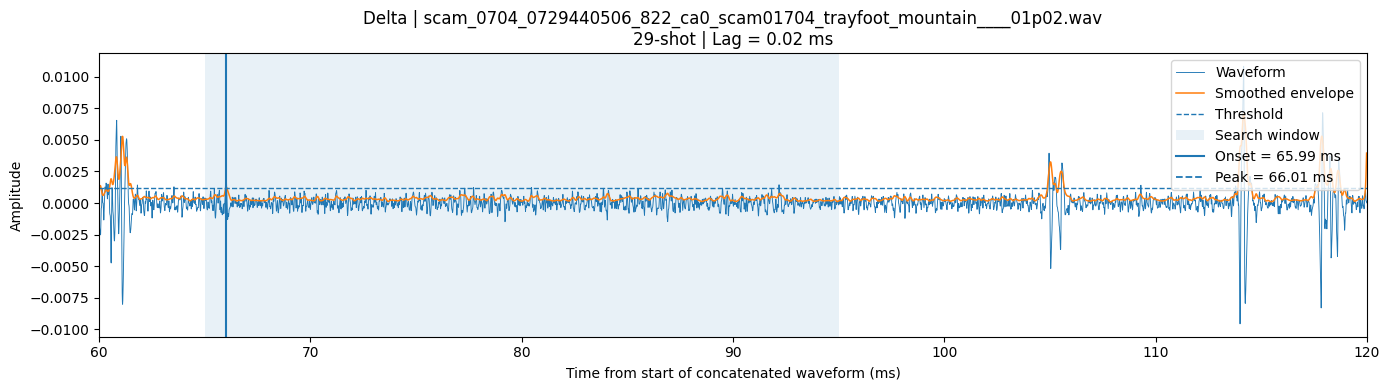

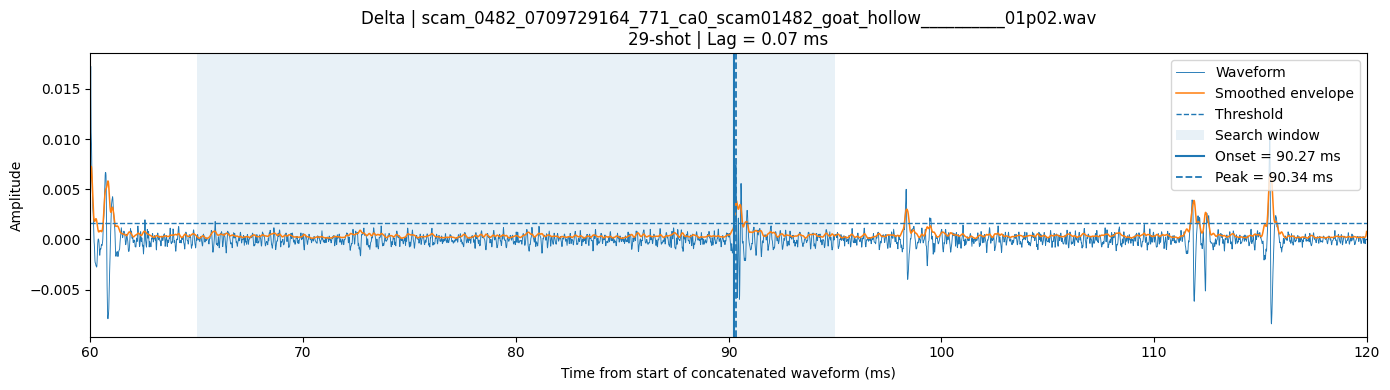

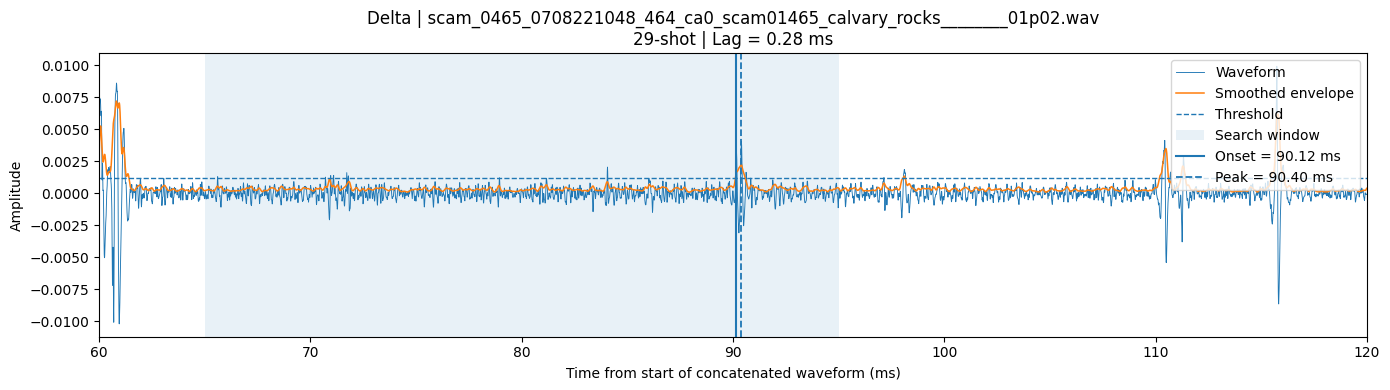

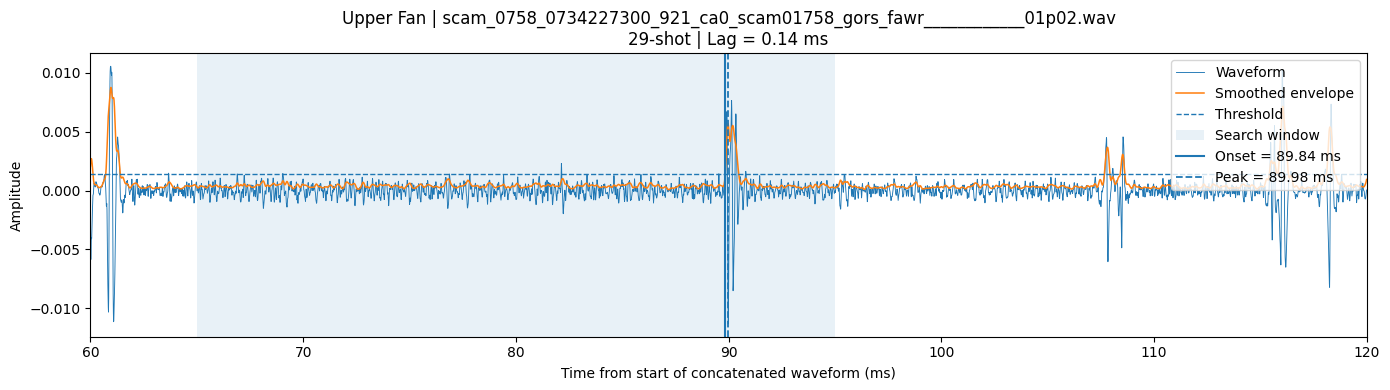

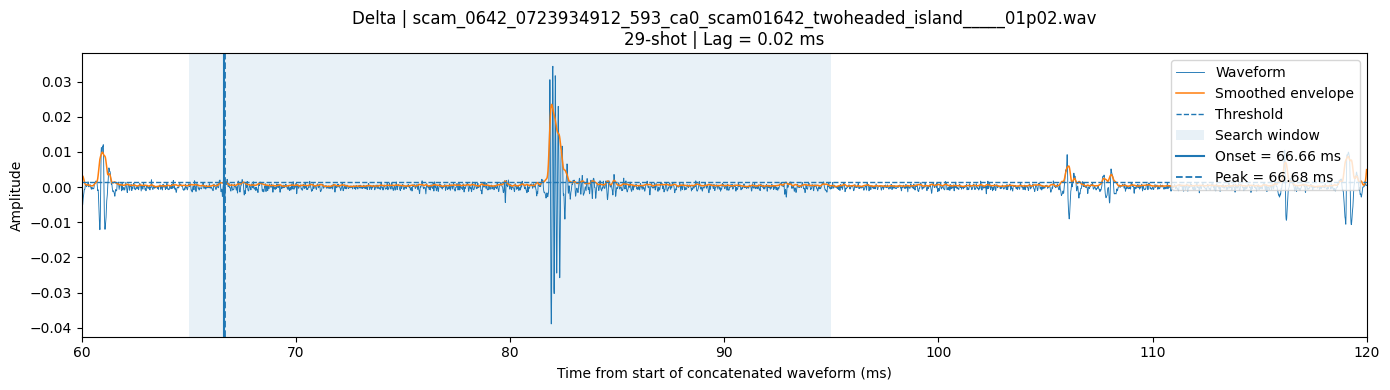

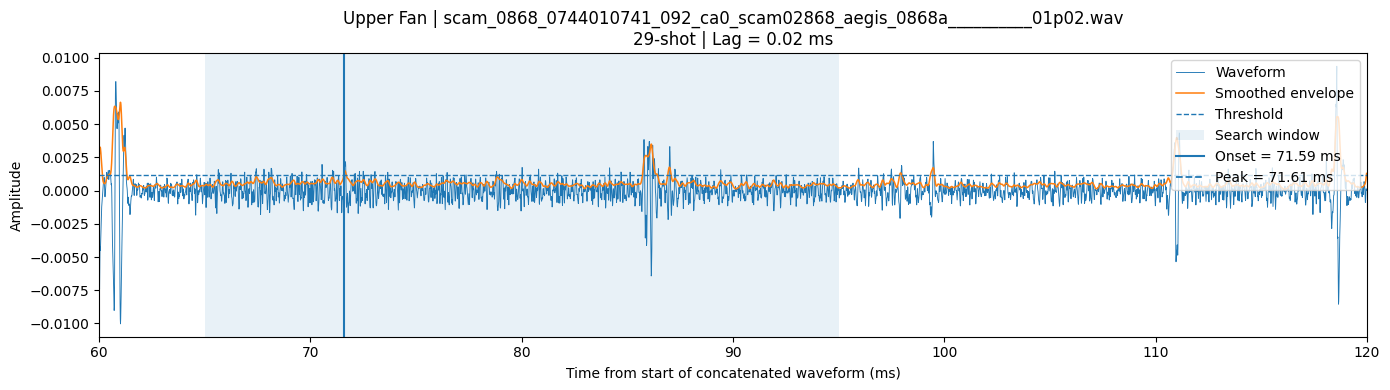

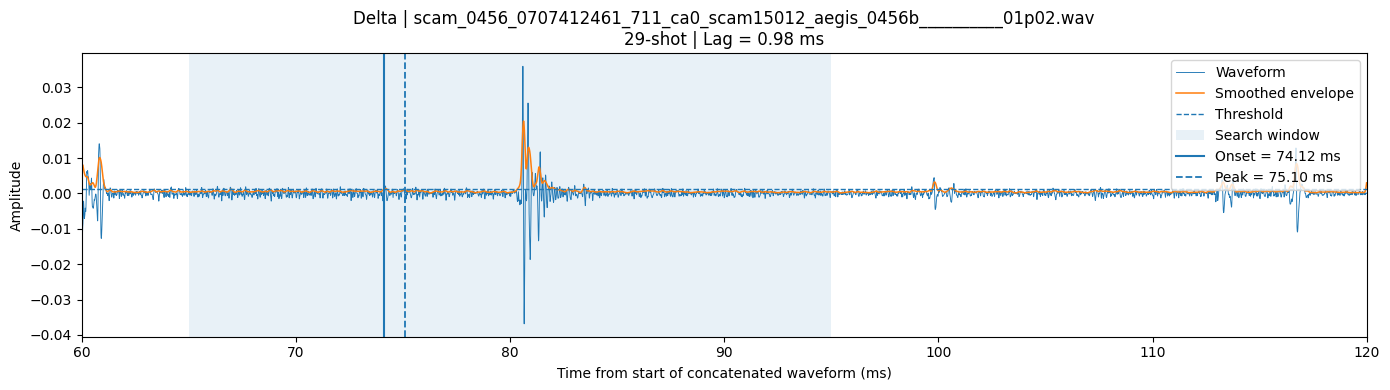

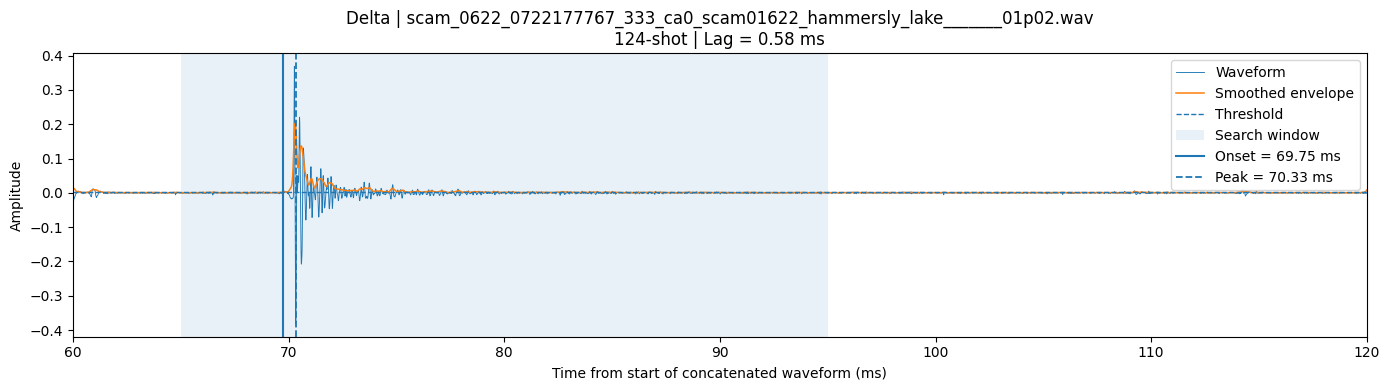

In [7]:
MAX_ACCEPTED_LAG_MS = 0.75

In [15]:
import pandas as pd
from pathlib import Path

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

meta_path = Path(
    r"C:\Users\cmkua\Downloads"
    r"\LIBS_acoustic_meta_sheet_v3_185.csv"
)

accepted_path = Path(
    r"C:\Users\cmkua\Downloads"
    r"\Concatenated Multishot WAVs"
    r"\LIBS Acoustic Results"
    r"\LIBS_acoustic_accepted_results.csv"
)

output_path = Path(
    r"C:\Users\cmkua\Downloads"
    r"\LIBS_acoustic_meta_sheet_v4_293.csv"
)

# ------------------------------------------------------------
# Load files
# ------------------------------------------------------------

meta = pd.read_csv(meta_path)
accepted = pd.read_csv(accepted_path)

print("Existing meta rows:", len(meta))
print("Accepted new rows:", len(accepted))

# ------------------------------------------------------------
# Confirm expected new-unit labels
# ------------------------------------------------------------

if "Unit" not in accepted.columns:
    raise KeyError(
        "The accepted-results file does not contain a 'Unit' column."
    )

print("\nAccepted Unit counts:")
print(accepted["Unit"].value_counts(dropna=False))

unexpected_units = set(
    accepted["Unit"].dropna().unique()
) - {"Delta", "Upper Fan"}

if unexpected_units:
    raise ValueError(
        f"Unexpected Unit values found: {unexpected_units}"
    )

# ------------------------------------------------------------
# Fill geological classification for new rows
# ------------------------------------------------------------

accepted["Formation"] = accepted["Unit"]
accepted["Member"] = pd.NA

# Optional broad region column
if "Region" not in meta.columns:
    meta["Region"] = "Crater Floor"
else:
    meta["Region"] = meta["Region"].fillna(
        "Crater Floor"
    )

accepted["Region"] = accepted["Unit"]

# Optional provenance columns
if "Dataset Source" not in meta.columns:
    meta["Dataset Source"] = "Crater Floor"

accepted["Dataset Source"] = accepted["Unit"]

if "Processing Version" not in meta.columns:
    meta["Processing Version"] = pd.NA

accepted["Processing Version"] = (
    "Short-clip find_peaks backtracking v2"
)

# ------------------------------------------------------------
# Match all columns
# ------------------------------------------------------------

all_columns = list(meta.columns)

for col in accepted.columns:
    if col not in all_columns:
        all_columns.append(col)

meta = meta.reindex(columns=all_columns)
accepted = accepted.reindex(columns=all_columns)

# ------------------------------------------------------------
# Concatenate
# ------------------------------------------------------------

combined = pd.concat(
    [meta, accepted],
    ignore_index=True
)

# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

expected_total = len(meta) + len(accepted)

if len(combined) != expected_total:
    raise RuntimeError(
        "Unexpected row-count change during concatenation."
    )

print("\nCombined rows:", len(combined))

print("\nFormation counts:")
print(
    combined["Formation"]
    .fillna("Missing")
    .value_counts()
)

print("\nRegion counts:")
print(
    combined["Region"]
    .fillna("Missing")
    .value_counts()
)

print("\nNew rows by Formation:")
print(
    combined.tail(len(accepted))["Formation"]
    .value_counts(dropna=False)
)

print(
    "\nExact duplicate rows:",
    combined.duplicated().sum()
)

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

combined.to_csv(output_path, index=False)

print("\nSaved new master metasheet to:")
print(output_path)

Existing meta rows: 185
Accepted new rows: 108

Accepted Unit counts:
Unit
Upper Fan    55
Delta        53
Name: count, dtype: int64

Combined rows: 293

Formation counts:
Formation
Maaz         97
Seitah       88
Upper Fan    55
Delta        53
Name: count, dtype: int64

Region counts:
Region
Crater Floor    185
Upper Fan        55
Delta            53
Name: count, dtype: int64

New rows by Formation:
Formation
Upper Fan    55
Delta        53
Name: count, dtype: int64

Exact duplicate rows: 0

Saved new master metasheet to:
C:\Users\cmkua\Downloads\LIBS_acoustic_meta_sheet_v4_293.csv
